# LSTM Pipeline

---

In [51]:
# Libraries
import math
import json
import warnings
import hashlib

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from dataclasses import dataclass
from typing import Iterable, Optional, Literal, Any, Union

from tqdm import tqdm
from tabulate import tabulate

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Statistical diagnostics
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.preprocessing import PowerTransformer

# SciPy stats
from scipy import stats
from scipy.stats import norm, kstest
from scipy.special import inv_boxcox

warnings.filterwarnings("ignore")

---

    - Function to format results into a table

In [52]:
def display_table(df: pd.DataFrame, title: str):
    """
    Display a formatted table for quick analysis and validation of results.

    Parameters
    ----------
    df (pd.DataFrame): DataFrame to be displayed.
    title (str): Title printed above the table.


    Returns
    -------
    df (pd.DataFrame)
    """

    print(f"\n{title}")
    if df is None:
        print("⚠️ No data provided.")
        return

    if isinstance(df, pd.Series):
        df = df.to_frame()

    if not isinstance(df, pd.DataFrame):
        print("⚠️ Invalid data format.")
        return

    if df.empty or df.shape[1] == 0:
        print("⚠️ No valid data or columns not found.")
        return

    colalign = ["center"] * len(df.columns)
    print(tabulate(df, headers="keys", tablefmt="fancy_grid", colalign=colalign, showindex=True, floatfmt=".8f"))

    - Function to compute Freedman–Diaconis bins

In [53]:
def freedman_diaconis_bins(df: pd.DataFrame):
    """
    Compute the number of histogram bins using the Freedman–Diaconis rule.
    The FD rule sets the bin width as: width = 2 * IQR / n^(1/3), where IQR is the interquartile range (Q3 - Q1) and n is the sample size.

    Parameters
    ----------
    df (pd.DataFrame): One-dimensional numeric data.

    Returns
    -------
    n_bins (int): Suggested number of bins.
    iqr_range (float): Suggested bin IQR range.
    """

    # Length of dataframe
    n = df.size
    if n == 0:
        return print("Dataframe is empty")
    
    # IQR range calculation
    q75, q25 = np.percentile(df, [75, 25])
    iqr = q75 - q25
    iqr_range = 2.0 * iqr / (n**(1/3))

    # Bins calculation
    data_range = np.max(df) - np.min(df)
    n_bins = int(math.ceil(data_range / iqr_range)) if iqr_range > 0 else 1

    return n_bins, iqr_range

---

## Upload and verification of Time-Series data

In [54]:
# Upload of Time-Series data
def load_series_from_csv(csv_path: str | Path, value_col: str, index_col: int | str = 0, dayfirst: bool = True, sort_index: bool = True, name: str = "y"):
    """
    Load a univariate time series from a CSV file.

    Notes
    -----
    - Expects the time index in `index_col`.
    - Converts index to datetime.
    - Returns a pd.Series with a clean name.
    """
    
    csv_path = Path(csv_path)
    df_raw = pd.read_csv(csv_path, index_col=index_col)
    df_raw.index = pd.to_datetime(df_raw.index, dayfirst=dayfirst, errors="coerce")
    df_raw = df_raw.rename_axis("Date")

    if df_raw.index.isna().any():
        raise ValueError("Warning: Datetime conversion produced NaT values in the index. Please check the CSV index format.")

    if sort_index:
        if not df_raw.index.is_monotonic_increasing:
            df_raw = df_raw.sort_index()
            print("Warning: Datetime index was not sorted. It has been automatically sorted.")

    if value_col not in df_raw.columns:
        raise KeyError(f"Column '{value_col}' not found. Available columns: {list(df_raw.columns)}")

    y = df_raw[value_col].copy()
    
    y.name = name
    return y

df_path = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\BTC-USD_2025-08-15.csv"
y_temp = load_series_from_csv(csv_path= df_path, value_col= "Close", name= "Close")

# Série de valores de fecho
# y_close = y_temp.copy()
# y = y_close.copy()

# Return type and transformations
ret_type = "L"                         # "S" simple returns | "L" log returns

# Return series
if ret_type == "S":
    y_returns = pd.Series(y_temp.pct_change(), name=f"Returns({ret_type}) series").dropna()
elif ret_type == "L":
    y_returns = pd.Series(np.log(y_temp / y_temp.shift(1)), name=f"Returns({ret_type}) series").dropna()
else:
    raise ValueError("ret_type deve ser 'S' ou 'L'.")
y = y_returns.copy()

In [55]:
# Time-Series data validation
def validate_series(y: pd.Series, min_len: int = 30):
    """
    Validate basic requirements for forecasting.

    - Ensures the input is a pandas Series
    - Ensures the series is not empty
    - Ensures no missing values exist (warns and stops execution)
    - Ensures minimum length requirement
    """
    
    if not isinstance(y, pd.Series):
        raise TypeError("Input must be a pandas Series.")

    if y.empty:
        raise ValueError("Series is empty.")

    y = y.copy()

    # Coerce to numeric if needed
    y = pd.to_numeric(y, errors="coerce")

    # Check for missing values (original NaN or coercion-induced NaN)
    n_missing = int(y.isna().sum())
    if n_missing > 0:
        warnings.warn(f"Series contains {n_missing} missing values. "
                      "Missing values must be treated before running the ARIMA pipeline.", category=UserWarning)
        raise ValueError("Pipeline stopped due to missing values. "
                         "Please handle NaNs explicitly (imputation, interpolation, or removal) before proceeding.")
    else:
        print("There is no missing values on dataset, pipeline is able to continue.")


    if len(y) < min_len:
        raise ValueError(f"Series too short for ARIMA pipeline (len={len(y)} < {min_len}).")

    return y

# Execute validation
data_verification = validate_series(y=y)

There is no missing values on dataset, pipeline is able to continue.


In [56]:
# Time-Series frequenci identification
def infer_frequency(y: pd.Series):
    """
    Infer the frequency of a DatetimeIndex.
    """

    freq = pd.infer_freq(y.index)

    if freq is None:
        warnings.warn("Could not reliably infer frequency from the DatetimeIndex. "
                      "Ensure the series is regular and without missing timestamps.")
        return None

    freq_map = {"D": "Daily",
                "B": "Business Daily",
                "W": "Weekly",
                "M": "Monthly",
                "Q": "Quarterly",
                "A": "Annual"}

    # Extract main frequency code
    main_freq = freq.split("-")[0]

    readable = freq_map.get(main_freq, f"Detected frequency: {freq}")

    print(f"Detected time frequency: {readable} ({freq})")

    return freq
    
y_freq = infer_frequency(y= y)

Detected time frequency: Daily (D)


In [57]:
# Evaluate Seasonality (strength via STL)
def seasonal_strength_stl(y: pd.Series, period: int):
    """
    Compute seasonality strength using STL decomposition.

    Returns
    -------
    strength : float in [0, 1] (best-effort), or 0 if it cannot be computed.
    """

    if period is None or period < 2:
        return 0

    # Conservative guard: STL needs enough cycles
    if len(y) < 2 * period + 5:
        return 0

    try:
        stl = STL(y, period=period, robust=True).fit()
        resid = stl.resid
        seasonal_plus_resid = stl.seasonal + stl.resid

        var_resid = np.nanvar(resid)
        var_sr = np.nanvar(seasonal_plus_resid)

        if var_sr <= 0:
            return 0

        strength = 1 - (var_resid / var_sr)
        return float(np.clip(strength, 0, 1))
    
    except Exception:
        return 0


def evaluate_seasonality(y: pd.Series, candidate_periods: Optional[Iterable[int]] = None):
    """
    Evaluate a set of candidate seasonal periods and return the best one.

    Returns
    -------
    best_period : int | None
    best_strength : float
    details : dict[period -> strength]
    """

    if candidate_periods is None:
        # Generic defaults
        candidate_periods = (2, 3, 4, 5, 6, 7, 12)

    details: dict[int, float] = {}
    for p in candidate_periods:
        details[int(p)] = seasonal_strength_stl(y, int(p))

    best_period = max(details, key=details.get) if len(details) else None
    best_strength = float(details[best_period]) if best_period is not None else 0

    return best_period, best_strength, details

y_freq = infer_frequency(y)

candidate_periods = (5, 7, 15, 30, 60, 120, 365)
best_p, best_s, details = evaluate_seasonality(y, candidate_periods=candidate_periods)

print("Best seasonal period:", best_p)
print("Best seasonal strength:", round(best_s, 4))

seasonal_summary = (pd.DataFrame({"period": list(details.keys()), "strength": list(details.values())}).sort_values("strength", ascending=False).reset_index(drop=True))
seasonal_summary["period"] = seasonal_summary["period"].astype(int).astype(str)
display_table(seasonal_summary, f"Seasonal strength table of {y.name}:")

Detected time frequency: Daily (D)
Best seasonal period: 120
Best seasonal strength: 0.1291

Seasonal strength table of Returns(L) series:
╒════╤══════════╤════════════╕
│    │  period  │   strength │
╞════╪══════════╪════════════╡
│ 0  │   120    │ 0.12914079 │
├────┼──────────┼────────────┤
│ 1  │    15    │ 0.10566964 │
├────┼──────────┼────────────┤
│ 2  │   365    │ 0.09080693 │
├────┼──────────┼────────────┤
│ 3  │    30    │ 0.08894658 │
├────┼──────────┼────────────┤
│ 4  │    60    │ 0.08375077 │
├────┼──────────┼────────────┤
│ 5  │    5     │ 0.06681629 │
├────┼──────────┼────────────┤
│ 6  │    7     │ 0.05070355 │
╘════╧══════════╧════════════╛


---

In [58]:
# Time-based train/val/test split
def time_split(y: pd.Series, test_size: float = 0.2, test_start: Optional[str | pd.Timestamp] = None, val_size: float = 0.3):
    """
    Split a time series into train/val/test.

    Parameters
    ----------
    test_start : str | pd.Timestamp | None
        If provided, test starts at this timestamp (inclusive).
        If None, uses test_size percentage.
    val_size : float
        Fraction of the training portion used as validation (0 disables validation split).

    Returns
    -------
    y_train, y_val, y_test
    """
    y = y.copy()
    if test_start is not None:
        test_start = pd.to_datetime(test_start)
        y_train_full = y.loc[y.index < test_start]
        y_test = y.loc[y.index >= test_start]
        if y_train_full.empty or y_test.empty:
            raise ValueError("Date-based split produced empty train or test. Check test_start.")
    else:
        if not (0 < test_size < 1):
            raise ValueError("test_size must be in (0,1).")
        cut = int(len(y) * (1 - test_size))
        y_train_full = y.iloc[:cut]
        y_test = y.iloc[cut:]
        if y_train_full.empty or y_test.empty:
            raise ValueError("Percentage split produced empty train or test. Adjust test_size.")

    if not (0 < val_size < 1):
        raise ValueError("val_size must be in (0,1).")

    cut_val = int(len(y_train_full) * (1 - val_size))
    y_train = y_train_full.iloc[:cut_val]
    y_val = y_train_full.iloc[cut_val:]

    if y_train.empty or y_val.empty:
        raise ValueError("Validation split produced empty train or val. Adjust val_size.")

    return y_train, y_val, y_test

y_train, y_val, y_test = time_split(y= y, test_start= None, val_size= 0.3)

print(f"Length of training dataset: {len(y_train)}")
print(f"Length of validation dataset: {len(y_val)}")
print(f"Length of test dataset: {len(y_test)}")

Length of training dataset: 2230
Length of validation dataset: 957
Length of test dataset: 797


In [59]:
# Target variable transformations
scale_transformer = None        # PowerTransformer(method="yeo-johnson", standardize=False) --- IGNORE ---
transformation_type = "yeo-johnson"     # "original" | "log1p" | "yeo-johnson"

# Target variable construction: volatility proxy
v_train = y_train.pow(2)
v_val = y_val.pow(2)
v_test = y_test.pow(2)

if transformation_type == "original":
    scale_factor = 0
    
    # Volatilidade proxy (squared returns)
    y_train = pd.Series(v_train, name=f"Variance_ret({ret_type}) series")
    y_val = pd.Series(v_val, name=f"Variance_ret({ret_type}) series")
    y_test = pd.Series(v_test, name=f"Variance_ret({ret_type}) series")

    serie_cache_name = y_train.name.strip("'").split()[0]

elif transformation_type == "log1p":
    scale_factor = 1e5

    v_train_scaled = v_train * scale_factor
    v_val_scaled = v_val * scale_factor
    v_test_scaled = v_test * scale_factor

    # Log transformation
    y_train = pd.Series(np.log1p(v_train_scaled), name=f"Log-Variance_ret({ret_type}) series_st")
    y_val = pd.Series(np.log1p(v_val_scaled), name=f"Log-Variance_ret({ret_type}) series_st")
    y_test = pd.Series(np.log1p(v_test_scaled), name=f"Log-Variance_ret({ret_type}) series_st")

    serie_cache_name = y_train.name.strip("'").split()[0]

elif transformation_type == "yeo-johnson":
    scale_factor = 1e5

    v_train_scaled = v_train * scale_factor
    v_val_scaled = v_val * scale_factor
    v_test_scaled = v_test * scale_factor

    # Yeo–Johnson transformation
    scale_transformer = PowerTransformer(method="yeo-johnson", standardize=False)
    y_train = pd.Series(scale_transformer.fit_transform(v_train_scaled.to_frame()).flatten(), index=v_train.index, name=f"Yeo-Johnson-Variance_ret({ret_type}) series")
    y_val = pd.Series(scale_transformer.transform(v_val_scaled.to_frame()).flatten(), index=v_val.index, name=f"Yeo-Johnson-Variance_ret({ret_type}) series")
    y_test = pd.Series(scale_transformer.transform(v_test_scaled.to_frame()).flatten(), index=v_test.index, name=f"Yeo-Johnson-Variance_ret({ret_type}) series")

    print("Yeo-Johnson lambda:", scale_transformer.lambdas_)
    print("Train transformed - min/max:", y_train.min(), y_train.max())
    print("Validation transformed - min/max:", y_val.min(), y_val.max())
    print("Test transformed - min/max:", y_test.min(), y_test.max())

    serie_cache_name = y_train.name.strip("'").split()[0]

else:
    raise ValueError("transformation_type must be 'original', 'log1p' or 'yeo-johnson'.")

Yeo-Johnson lambda: [-0.05382974]
Train transformed - min/max: -0.0 7.721414145900821
Validation transformed - min/max: 3.7478080993648856e-05 6.510926392578827
Test transformed - min/max: 4.4714553224756766e-06 5.9561294437658825


In [60]:
# Evaluate Seasonality (strength via STL)
def seasonal_strength_stl(y: pd.Series, period: int):
    """
    Compute seasonality strength using STL decomposition.

    Returns
    -------
    strength : float in [0, 1] (best-effort), or 0 if it cannot be computed.
    """

    if period is None or period < 2:
        return 0

    # Conservative guard: STL needs enough cycles
    if len(y) < 2 * period + 5:
        return 0

    try:
        stl = STL(y, period=period, robust=True).fit()
        resid = stl.resid
        seasonal_plus_resid = stl.seasonal + stl.resid

        var_resid = np.nanvar(resid)
        var_sr = np.nanvar(seasonal_plus_resid)

        if var_sr <= 0:
            return 0

        strength = 1 - (var_resid / var_sr)
        return float(np.clip(strength, 0, 1))
    
    except Exception:
        return 0


def evaluate_seasonality(y: pd.Series, candidate_periods: Optional[Iterable[int]] = None):
    """
    Evaluate a set of candidate seasonal periods and return the best one.

    Returns
    -------
    best_period : int | None
    best_strength : float
    details : dict[period -> strength]
    """

    if candidate_periods is None:
        # Generic defaults
        candidate_periods = (2, 3, 4, 5, 6, 7, 12)

    details: dict[int, float] = {}
    for p in candidate_periods:
        details[int(p)] = seasonal_strength_stl(y, int(p))

    best_period = max(details, key=details.get) if len(details) else None
    best_strength = float(details[best_period]) if best_period is not None else 0

    return best_period, best_strength, details

y_freq = infer_frequency(y.pow(2))

candidate_periods = (5, 7, 15, 30, 60, 120, 365)
best_p, best_s, details = evaluate_seasonality(y.pow(2), candidate_periods=candidate_periods)

print("Best seasonal period:", best_p)
print("Best seasonal strength:", round(best_s, 4))

seasonal_summary = (pd.DataFrame({"period": list(details.keys()), "strength": list(details.values())}).sort_values("strength", ascending=False).reset_index(drop=True))
seasonal_summary["period"] = seasonal_summary["period"].astype(int).astype(str)
display_table(seasonal_summary, f"Seasonal strength table of {y_train.name}:")

Detected time frequency: Daily (D)
Best seasonal period: 365
Best seasonal strength: 0.5148

Seasonal strength table of Yeo-Johnson-Variance_ret(L) series:
╒════╤══════════╤════════════╕
│    │  period  │   strength │
╞════╪══════════╪════════════╡
│ 0  │   365    │ 0.51480359 │
├────┼──────────┼────────────┤
│ 1  │    5     │ 0.07200456 │
├────┼──────────┼────────────┤
│ 2  │    60    │ 0.06347951 │
├────┼──────────┼────────────┤
│ 3  │    7     │ 0.04992226 │
├────┼──────────┼────────────┤
│ 4  │   120    │ 0.04655920 │
├────┼──────────┼────────────┤
│ 5  │    15    │ 0.03395419 │
├────┼──────────┼────────────┤
│ 6  │    30    │ 0.00000000 │
╘════╧══════════╧════════════╛


---

## Criação dos modelos LSTM

In [61]:
# Multi-horizon backtesting block generator (rolling/expanding) for LSTM
BacktestMode = Literal["rolling", "expanding", "none"]

@dataclass(frozen=True)
class BacktestBlock:
    """
    A single origin block for multi-horizon evaluation.
    """
    origin: int
    train: pd.Series
    test: pd.Series


def generate_backtest_blocks(y: pd.Series, horizons: Iterable[int], mode: BacktestMode = "rolling", window: Optional[int] = None, step: int = 1, lookback: int = 1,
                             min_train_size: Optional[int] = None):
    """
    Generate blocks for multi-horizon forecasting evaluation.

    Parameters
    ----------
    y (pd.Series): Full target series, usually the training portion only when nested splits are used.

    horizons (Iterable[int]): Forecast horizons, e.g. (1, 7, 15, 30, 120).

    mode (BacktestMode): {"rolling", "expanding", "none"}
                         Rolling: fixed training window.
                         Expanding: increasing training window from the beginning.
                         None: single origin using the provided window, or the default.

    window (int | None): Size of the training window for rolling mode, or the minimum initial window
                         for expanding/none. If None, defaults to 60% of the series length.

    step (int): Step between forecast origins.

    lookback (int): Number of past observations required to create each LSTM input sequence.

    min_train_size (int | None): Minimum number of observations required in each training block.
                                 If None, defaults to lookback + 1.

    Returns
    -------
    blocks: list[BacktestBlock]
    """

    if not isinstance(y, pd.Series):
        raise TypeError("y must be a pandas Series.")

    y = y.copy()

    if y.empty:
        raise ValueError("y cannot be empty.")

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if step < 1:
        raise ValueError("step must be >= 1.")

    if lookback < 1:
        raise ValueError("lookback must be >= 1.")

    if min_train_size is None:
        min_train_size = lookback + 1

    if min_train_size <= lookback:
        raise ValueError("min_train_size must be greater than lookback.")

    n = len(y)

    if window is None:
        window = int(n * 0.60)

    if window < min_train_size:
        raise ValueError(f"window must be at least min_train_size={min_train_size}. Got window={window}.")

    # Need at least window + hmax points
    if n < window + hmax:
        raise ValueError(f"Series too short for requested horizons: need >= {window + hmax}, got {n}.")

    blocks: list[BacktestBlock] = []

    if mode == "none":
        origin = window
        train = y.iloc[:origin].copy()
        test = y.iloc[origin:origin + hmax].copy()

        blocks.append(BacktestBlock(origin=origin, train=train, test=test))
        return blocks

    # Generate multiple origins
    start_origin = window
    end_origin = n - hmax

    for origin in range(start_origin, end_origin + 1, step):

        if mode == "rolling":
            train_start = origin - window
            train = y.iloc[train_start:origin].copy()

        elif mode == "expanding":
            train = y.iloc[:origin].copy()

        else:
            raise ValueError("Invalid mode. Use 'rolling', 'expanding', or 'none'.")

        if len(train) < min_train_size:
            continue

        test = y.iloc[origin:origin + hmax].copy()

        blocks.append(BacktestBlock(origin=origin, train=train, test=test))

    if len(blocks) == 0:
        raise ValueError("No valid backtesting blocks were generated. Check window, lookback, step and horizons.")

    return blocks

In [62]:
# Identify and invert transformations applied to the volatility proxy
def identify_variance_transformation_from_series_name(y: pd.Series):
    """
    Identify the transformation applied to the volatility proxy from the series name.
    The transformation is inferred from the name attribute of the input series.

    Parameters
    ----------
    y (pd.Series): Volatility-proxy series whose name identifies the applied transformation.

    Returns
    -------
    transformation (str): Identified transformation. Possible values are "original", "log1p", "yeo-johnson" or "unknown".
    """

    name = str(getattr(y, "name", ""))

    if "Yeo-Johnson-Variance_ret" in name:
        # print(y.name)
        return "yeo-johnson"

    if "Log-Variance_ret" in name:
        # print(y.name)
        return "log1p"

    if "Variance_ret" in name:
        # print(y.name)
        return "original"

    return "unknown"


def inverse_variance_transformation(values, reference_series: pd.Series, yeo_johnson_transformer: Optional[PowerTransformer] = None, clip_negative: bool = True):
    """
    Invert a transformation applied to the volatility proxy.
    Forecasts and observed values are converted back to the original volatility-proxy scale.

    Parameters
    ----------
    values (array-like): Values to invert. These may be forecasts or observed transformed values.

    reference_series (pd.Series): Series whose name identifies the transformation applied to the volatility proxy.

    yeo_johnson_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer required when the transformation is Yeo-Johnson.

    clip_negative (bool, default=True): Whether to replace negative inverted values with zero.

    Returns
    -------
    inverted (np.ndarray): Values converted to the original volatility-proxy scale.
    """

    transformation = identify_variance_transformation_from_series_name(reference_series)
    # print(f"Identified transformation for series '{reference_series.name}': {transformation}")

    values = np.asarray(values, dtype=float).reshape(-1, 1)

    if values.shape[0] == 0:
        return np.array([], dtype=float)

    if transformation == "original":
        inverted = values.flatten()

    elif transformation == "log1p":
        inverted_scaled = np.expm1(values).flatten()
        inverted = inverted_scaled / scale_factor
        inverted = np.asarray(inverted, dtype=float)
        inverted = np.where(np.isfinite(inverted), inverted, np.nan)
        
    elif transformation == "yeo-johnson":
        if yeo_johnson_transformer is None:
            raise ValueError("yeo_johnson_transformer is required for Yeo-Johnson transformation.")
        inverted_scaled = yeo_johnson_transformer.inverse_transform(values).flatten()
        inverted = inverted_scaled / scale_factor
        inverted = np.asarray(inverted, dtype=float)
        inverted = np.where(np.isfinite(inverted), inverted, np.nan)

    else:
        raise ValueError(f"Unknown transformation for series '{reference_series.name}'.")

    if clip_negative:
        inverted = np.maximum(inverted, 0)

    return inverted

In [63]:
# Metrics RMSE, MAPE, sMAPE and QLIKE
def rmse(y_true: np.ndarray, y_pred: np.ndarray):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    if not np.any(mask):
        return np.nan
    
    rmse_result = float(np.sqrt(np.nanmean((y_true - y_pred) ** 2)))
    return rmse_result

def mape_smape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    if not np.any(mask):
        return np.nan
    
    mape = float(np.nanmean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100)
    smape = float(np.nanmean(2 * np.abs(y_true - y_pred) / np.maximum(np.abs(y_true) + np.abs(y_pred), eps)) * 100)
    return mape, smape

def qlike(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    if not np.any(mask):
        return np.nan
    
    qlike_result = float(np.nanmean(np.log(np.maximum(y_pred, eps)) + (np.maximum(y_true, eps) / (np.maximum(y_pred, eps)))))
    return qlike_result

In [64]:
# LSTM configuration dataclass
@dataclass(frozen=True)
class LSTMConfig:
    """
    Configuration class for an LSTM forecasting model.

    Parameters
    ----------
    lookback (int): Number of past observations used as input sequence.

    n_units (int): Number of LSTM units in each recurrent layer.

    n_layers (int): Number of stacked LSTM layers.

    dropout (float): Dropout rate applied after LSTM layers.

    recurrent_dropout (float): Dropout rate applied to recurrent connections inside the LSTM layer.

    dense_units (int | None): Number of units in an optional dense hidden layer before the output layer.
                              If None, no intermediate dense layer is used.

    learning_rate (float): Learning rate used by the optimizer.

    batch_size (int): Number of samples per gradient update.

    epochs (int): Maximum number of training epochs.

    loss (str): Loss function used during model training.

    optimizer (str): Optimizer used during model training.

    output_size (int): Number of output neurons. For direct multi-horizon forecasting, this should
                       be equal to the number of forecast horizons.
    """

    lookback: int
    n_units: int
    n_layers: int = 1
    dropout: float = 0
    recurrent_dropout: float = 0
    dense_units: Optional[int] = None
    learning_rate: float = 0.001
    batch_size: int = 32
    epochs: int = 100
    loss: str = "mse"
    optimizer: str = "adam"
    output_size: int = 1

    def to_dict(self):
        """
        Convert the configuration into a dictionary.

        Returns
        -------
        out (dict): Dictionary representation of the LSTM configuration.
        """

        return {"lookback": self.lookback,
                "n_units": self.n_units,
                "n_layers": self.n_layers,
                "dropout": self.dropout,
                "recurrent_dropout": self.recurrent_dropout,
                "dense_units": self.dense_units,
                "learning_rate": self.learning_rate,
                "batch_size": self.batch_size,
                "epochs": self.epochs,
                "loss": self.loss,
                "optimizer": self.optimizer,
                "output_size": self.output_size}

    def to_label(self):
        """
        Build a compact human-readable label for tables and logs.

        Returns
        -------
        label (str): Human-readable LSTM configuration label.
        """

        dense_label = "None" if self.dense_units is None else str(self.dense_units)

        return (f"LSTM(lookback={self.lookback}, "
                f"units={self.n_units}, "
                f"layers={self.n_layers}, "
                f"dropout={self.dropout}, "
                f"rec_dropout={self.recurrent_dropout}, "
                f"dense={dense_label}, "
                f"lr={self.learning_rate}, "
                f"batch={self.batch_size}, "
                f"epochs={self.epochs}, "
                f"loss='{self.loss}', "
                f"optimizer='{self.optimizer}', "
                f"output={self.output_size})")

In [65]:
# LSTM configuration grid builder
def build_lstm_config_grid(lookback_values: Iterable[int] = (3, 5, 7, 10, 14, 21, 30, 60), n_units_values: Iterable[int] = (32, 64), n_layers_values: Iterable[int] = (1, 2),
                           dropout_values: Iterable[float] = (0, 0.2), recurrent_dropout_values: Iterable[float] = (0,), dense_units_values: Iterable[Optional[int]] = (None,),
                           learning_rate_values: Iterable[float] = (0.001,), batch_size_values: Iterable[int] = (32,), epochs_values: Iterable[int] = (200,),
                           loss_values: Iterable[str] = ("mse",), optimizer_values: Iterable[str] = ("adam",), output_size: int = 1):
    """
    Build a compact LSTM configuration grid.

    Parameters
    ----------
    lookback_values (Iterable[int]): Candidate input sequence lengths.

    n_units_values (Iterable[int]): Candidate number of LSTM units per recurrent layer.

    n_layers_values (Iterable[int]): Candidate number of stacked LSTM layers.

    dropout_values (Iterable[float]): Candidate dropout rates applied after LSTM layers.

    recurrent_dropout_values (Iterable[float]): Candidate dropout rates applied to recurrent connections.

    dense_units_values (Iterable[int | None]): Candidate number of units in an optional dense hidden layer.
                                               If None, no intermediate dense layer is used.

    learning_rate_values (Iterable[float]): Candidate learning rates.

    batch_size_values (Iterable[int]): Candidate batch sizes.

    epochs_values (Iterable[int]): Candidate maximum number of training epochs.

    loss_values (Iterable[str]): Candidate loss functions.

    optimizer_values (Iterable[str]): Candidate optimizers.

    output_size (int, default=1): Number of output neurons. For direct multi-horizon forecasting,
                                  this should be equal to the number of forecast horizons.

    Returns
    -------
    grid (list[LSTMConfig]): List of LSTM configurations.
    """

    if output_size < 1:
        raise ValueError("output_size must be greater than or equal to 1.")

    grid = []

    for lookback in lookback_values:
        for n_units in n_units_values:
            for n_layers in n_layers_values:
                for dropout in dropout_values:
                    for recurrent_dropout in recurrent_dropout_values:
                        for dense_units in dense_units_values:
                            for learning_rate in learning_rate_values:
                                for batch_size in batch_size_values:
                                    for epochs in epochs_values:
                                        for loss in loss_values:
                                            for optimizer in optimizer_values:

                                                if int(lookback) < 1:
                                                    raise ValueError("lookback values must be greater than or equal to 1.")

                                                if int(n_units) < 1:
                                                    raise ValueError("n_units values must be greater than or equal to 1.")

                                                if int(n_layers) < 1:
                                                    raise ValueError("n_layers values must be greater than or equal to 1.")

                                                if not 0 <= float(dropout) < 1:
                                                    raise ValueError("dropout values must be in the interval [0, 1).")

                                                if not 0 <= float(recurrent_dropout) < 1:
                                                    raise ValueError("recurrent_dropout values must be in the interval [0, 1).")

                                                if dense_units is not None and int(dense_units) < 1:
                                                    raise ValueError("dense_units must be None or greater than or equal to 1.")

                                                if float(learning_rate) <= 0:
                                                    raise ValueError("learning_rate values must be positive.")

                                                if int(batch_size) < 1:
                                                    raise ValueError("batch_size values must be greater than or equal to 1.")

                                                if int(epochs) < 1:
                                                    raise ValueError("epochs values must be greater than or equal to 1.")

                                                grid.append(LSTMConfig(lookback=int(lookback),
                                                                       n_units=int(n_units),
                                                                       n_layers=int(n_layers),
                                                                       dropout=float(dropout),
                                                                       recurrent_dropout=float(recurrent_dropout),
                                                                       dense_units=None if dense_units is None else int(dense_units),
                                                                       learning_rate=float(learning_rate),
                                                                       batch_size=int(batch_size),
                                                                       epochs=int(epochs),
                                                                       loss=str(loss),
                                                                       optimizer=str(optimizer),
                                                                       output_size=int(output_size)))

    return grid

In [66]:
# LSTM configuration compatibility check
def lstm_config_compatible(y: pd.Series, cfg: LSTMConfig, hmax: int = 1, min_samples: int = 10, n_outputs: Optional[int] = None):
    """
    Enforce basic LSTM constraints to avoid unnecessary exceptions.

    Parameters
    ----------
    y (pd.Series): Time series used to create LSTM sequences.

    cfg (LSTMConfig): LSTM configuration.

    hmax (int, default=1): Maximum forecast horizon required when creating supervised samples.

    min_samples (int, default=10): Minimum number of supervised samples required after applying lookback.

    n_outputs (int | None, default=None): Expected number of output neurons. For direct multi-horizon forecasting,
                                          this should be equal to len(horizons). If None, this check is skipped.

    Returns
    -------
    compatible (bool): True if the configuration is compatible with the available data.
    """

    if not isinstance(y, pd.Series):
        return False

    if len(y) == 0:
        return False

    if cfg.lookback < 1:
        return False

    if cfg.n_units < 1:
        return False

    if cfg.n_layers < 1:
        return False

    if not (0 <= cfg.dropout < 1):
        return False

    if not (0 <= cfg.recurrent_dropout < 1):
        return False

    if cfg.dense_units is not None and cfg.dense_units < 1:
        return False

    if cfg.learning_rate <= 0:
        return False

    if cfg.batch_size < 1:
        return False

    if cfg.epochs < 1:
        return False

    if cfg.output_size < 1:
        return False

    if n_outputs is not None and cfg.output_size != int(n_outputs):
        return False

    if hmax < 1:
        return False

    if min_samples < 1:
        return False

    y_clean = y.replace([np.inf, -np.inf], np.nan).dropna()

    if len(y_clean) == 0:
        return False

    n_samples = len(y_clean) - cfg.lookback - hmax + 1

    if n_samples < min_samples:
        return False

    return True

In [67]:
# Create supervised LSTM sequences
def make_lstm_sequences(y: pd.Series, lookback: int, horizons: tuple[int, ...]):
    """
    Convert a univariate time series into supervised LSTM sequences.

    Parameters
    ----------
    y (pd.Series): Input time series.

    lookback (int): Number of past observations used as input sequence.

    horizons (tuple[int, ...]): Forecast horizons to predict, e.g. (1, 7, 15, 30, 120).

    Returns
    -------
    x (np.ndarray): Input sequences with shape (n_samples, lookback, 1).

    y_targets (np.ndarray): Multi-horizon targets with shape (n_samples, n_horizons).

    target_index (pd.Index): Dates or index values associated with the first forecast horizon.
    """

    if not isinstance(y, pd.Series):
        raise TypeError("y must be a pandas Series.")

    if lookback < 1:
        raise ValueError("lookback must be greater than or equal to 1.")

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    values = y.to_numpy(dtype=float)
    index = y.index

    if not np.all(np.isfinite(values)):
        raise ValueError("y contains NaN or infinite values. Clean the series before creating LSTM sequences.")

    hmax = max(horizons)

    x_rows = []
    y_rows = []
    target_dates = []

    for i in range(lookback, len(values) - hmax + 1):

        # Keep chronological order for LSTM: oldest observation -> most recent observation
        x_i = values[i - lookback:i]

        y_i = [values[i + h - 1] for h in horizons]

        x_rows.append(x_i)
        y_rows.append(y_i)
        target_dates.append(index[i])

    if len(x_rows) == 0:
        raise ValueError("No LSTM sequences were created. Check lookback, horizons and series length.")

    x = np.asarray(x_rows, dtype=float)
    y_targets = np.asarray(y_rows, dtype=float)

    # LSTM expects shape: (samples, timesteps, features)
    x = x.reshape((x.shape[0], x.shape[1], 1))

    target_index = pd.Index(target_dates)

    return x, y_targets, target_index

In [68]:
# Build LSTM model
def build_lstm_model(cfg: LSTMConfig):
    """
    Build an LSTM model from a given configuration.

    Parameters
    ----------
    cfg (LSTMConfig): LSTM configuration.

    Returns
    -------
    model (tensorflow.keras.Model): Compiled LSTM model.
    """

    model = Sequential()

    for layer_idx in range(cfg.n_layers):

        is_first_layer = layer_idx == 0
        is_last_lstm_layer = layer_idx == cfg.n_layers - 1

        return_sequences = not is_last_lstm_layer

        if is_first_layer:
            model.add(LSTM(units=cfg.n_units,
                           return_sequences=return_sequences,
                           dropout=cfg.dropout,
                           recurrent_dropout=cfg.recurrent_dropout,
                           input_shape=(cfg.lookback, 1)))

        else:
            model.add(LSTM(units=cfg.n_units,
                           return_sequences=return_sequences,
                           dropout=cfg.dropout,
                           recurrent_dropout=cfg.recurrent_dropout))

    if cfg.dense_units is not None:
        model.add(Dense(cfg.dense_units, activation="relu"))

    model.add(Dense(cfg.output_size))

    if cfg.optimizer.lower() == "adam":
        optimizer = Adam(learning_rate=cfg.learning_rate)
    else:
        raise ValueError(f"Unsupported optimizer: {cfg.optimizer}")

    model.compile(optimizer=optimizer, loss=cfg.loss)

    return model

In [69]:
# Fit LSTM and forecast the next multi-horizon values
def forecast_lstm(y_train: pd.Series, horizons: tuple[int, ...], cfg: LSTMConfig, scaler_type: str = "minmax", validation_size: float = 0.2, patience: int = 15,
                  reduce_lr_patience: int = 7, min_samples: int = 30, random_state: int = 42, verbose: int = 0):
    """
    Fit an LSTM model using only the available training/history series and forecast the requested horizons.
    The function uses an internal temporal validation split within y_train only for EarlyStopping and ReduceLROnPlateau.

    Parameters
    ----------
    y_train (pd.Series): Historical series available up to the forecast origin.

    horizons (tuple[int, ...]): Forecast horizons, e.g. (1, 7, 15, 30, 120).

    cfg (LSTMConfig): LSTM configuration.

    scaler_type (str, default="minmax"): Scaling method. Currently supports "minmax".

    validation_size (float, default=0.2): Fraction of y_train used as internal validation for EarlyStopping.

    patience (int, default=15): EarlyStopping patience.

    reduce_lr_patience (int, default=7): ReduceLROnPlateau patience.

    min_samples (int, default=30): Minimum number of supervised samples required.

    random_state (int, default=42): Random seed for reproducibility.

    verbose (int, default=0): Keras verbosity level.

    Returns
    -------
    result (dict): Dictionary containing model, history, scaler, forecasts and configuration.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if cfg.output_size != len(horizons):
        raise ValueError(f"cfg.output_size must be equal to len(horizons). "
                         f"Got output_size={cfg.output_size} and len(horizons)={len(horizons)}.")

    if not lstm_config_compatible(y=y_train, cfg=cfg, hmax=hmax, min_samples=min_samples):
        raise ValueError(f"LSTM configuration is not compatible with y_train: {cfg.to_label()}")

    if not (0 < validation_size < 1):
        raise ValueError("validation_size must be between 0 and 1.")

    cut_val = int(len(y_train) * (1 - validation_size))

    y_subtrain = y_train.iloc[:cut_val].copy()
    y_subtrain_val = y_train.iloc[cut_val:].copy()

    if y_subtrain.empty or y_subtrain_val.empty:
        raise ValueError("Internal train/validation split produced empty data.")

    if scaler_type == "minmax":
        scaler = MinMaxScaler()
    else:
        raise ValueError("Only scaler_type='minmax' is currently supported.")

    # Fit scaler only on the internal training subset.
    scaler.fit(y_subtrain.to_numpy(dtype=float).reshape(-1, 1))

    y_subtrain_scaled = pd.Series(scaler.transform(y_subtrain.to_numpy(dtype=float).reshape(-1, 1)).flatten(), index=y_subtrain.index, name=y_subtrain.name)

    y_train_scaled = pd.Series(scaler.transform(y_train.to_numpy(dtype=float).reshape(-1, 1)).flatten(), index=y_train.index, name=y_train.name)

    # Training sequences are created only from y_subtrain.
    x_train, y_train_supervised, _ = make_lstm_sequences(y=y_subtrain_scaled, lookback=cfg.lookback, horizons=horizons)

    # Internal validation sequences are created from the full y_train period, but only rows whose forecast origin is after y_subtrain are used.
    x_all, y_all, target_index = make_lstm_sequences(y=y_train_scaled, lookback=cfg.lookback, horizons=horizons)

    subtrain_val_mask = target_index > y_subtrain.index[-1]

    x_subtrain_val = x_all[subtrain_val_mask]
    y_subtrain_val_supervised = y_all[subtrain_val_mask]

    if len(x_train) == 0 or len(x_subtrain_val) == 0:
        raise ValueError("Empty training or internal validation sequences. Check lookback, horizons, validation_size and series length.")

    tf.keras.backend.clear_session()
    tf.random.set_seed(random_state)
    np.random.seed(random_state)

    model = build_lstm_model(cfg)

    early_stop = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=reduce_lr_patience, min_lr=1e-6)

    history = model.fit(x_train,
                        y_train_supervised,
                        validation_data=(x_subtrain_val, y_subtrain_val_supervised),
                        epochs=cfg.epochs,
                        batch_size=cfg.batch_size,
                        callbacks=[early_stop, reduce_lr],
                        verbose=verbose,
                        shuffle=False)

    # Forecast from the last available lookback window in y_train.
    last_window_scaled = y_train_scaled.iloc[-cfg.lookback:].to_numpy(dtype=float)
    x_forecast = last_window_scaled.reshape(1, cfg.lookback, 1)

    y_hat_scaled = model.predict(x_forecast, verbose=0).reshape(-1)

    y_hat = scaler.inverse_transform(y_hat_scaled.reshape(-1, 1)).flatten()

    result = {"model": model,
              "history": history,
              "scaler": scaler,
              "cfg": cfg,
              "horizons": horizons,
              "forecast_scaled": y_hat_scaled,
              "forecast": y_hat,
              "mean_epochs_trained": len(history.history["loss"]),
              "final_train_loss": float(history.history["loss"][-1]),
              "final_val_loss": float(history.history["val_loss"][-1]),
              "best_val_loss": float(np.min(history.history["val_loss"]))}

    return result

In [70]:
# Evaluate a list of LSTM configs on a single origin
def evaluate_lstm_configs_single_origin(y_train: pd.Series, y_test_hmax: pd.Series, cfgs: list[LSTMConfig], horizons: Iterable[int], validation_size: float = 0.2,
                                        scaler_type: str = "minmax", metric: str = "RMSE", patience: int = 15, reduce_lr_patience: int = 7, min_samples: int = 30,
                                        random_state: int = 42, verbose: int = 0, scale_transformer: Optional[PowerTransformer] = None, origin: Optional[int] = None,
                                        origin_date: Optional[pd.Timestamp] = None):
    """
    Evaluate a fixed list of LSTM configurations on a single forecast origin.

    Each LSTM configuration is fitted using only y_train. Forecasts are produced directly for the specified horizons and evaluated against y_test_hmax.

    Parameters
    ----------
    y_train (pd.Series): Time series available up to the forecast origin.

    y_test_hmax (pd.Series): Future observations after the forecast origin. Must contain at least max(horizons) observations.

    cfgs (list[LSTMConfig]): List of LSTM configurations to evaluate.

    horizons (Iterable[int]): Forecast horizons, for example (1, 7, 15, 30, 120).

    validation_size (float, default=0.2): Fraction of y_train used as internal validation inside forecast_lstm.

    scaler_type (str, default="minmax"): Scaling method used inside the LSTM forecasting function.

    metric (str, default="RMSE"): Main metric used to rank configurations. Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    patience (int, default=15): EarlyStopping patience.

    reduce_lr_patience (int, default=7): ReduceLROnPlateau patience.

    min_samples (int, default=30): Minimum number of supervised samples required.

    random_state (int, default=42): Random seed for reproducibility.

    verbose (int, default=0): Keras training verbosity.

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer required when the target series uses a Yeo-Johnson transformation.

    origin (int | None, default=None): Forecast origin position.

    origin_date (pd.Timestamp | None, default=None): Forecast origin date.

    Returns
    -------
    df_metrics (pd.DataFrame): DataFrame with configuration parameters, per-horizon metrics and aggregate scores.

    df_forecasts (pd.DataFrame): DataFrame with point forecasts, observed values and residuals by configuration and horizon.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if len(y_test_hmax) < hmax:
        raise ValueError(f"y_test_hmax must contain at least {hmax} observations. Got {len(y_test_hmax)}.")

    if not (0 < validation_size < 1):
        raise ValueError("validation_size must be between 0 and 1.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    y_train = y_train.copy()
    y_test_hmax_input = y_test_hmax.iloc[:hmax].copy()

    if len(y_train) == 0 or len(y_test_hmax_input) < hmax:
        raise ValueError("Empty or insufficient train/test data after preprocessing.")

    if not np.all(np.isfinite(y_train.to_numpy(dtype=float))):
        raise ValueError("y_train contains NaN or infinite values.")

    if not np.all(np.isfinite(y_test_hmax_input.to_numpy(dtype=float))):
        raise ValueError("y_test_hmax contains NaN or infinite values within the required horizon window.")

    # Future observations in the input/model scale, limited to hmax
    y_test_hmax_values = y_test_hmax_input.values.astype(float)

    # Invert observed future values to original volatility-proxy scale
    y_test_hmax_original = inverse_variance_transformation(values=y_test_hmax_values,
                                                           reference_series=y_test_hmax,
                                                           yeo_johnson_transformer=scale_transformer,
                                                           clip_negative=True)

    metric_rows = []
    forecast_rows = []

    for cfg in tqdm(cfgs, desc="LSTM configs", unit="cfg", leave=False):

        if cfg.output_size != len(horizons):
            continue

        if not lstm_config_compatible(y=y_train,
                                        cfg=cfg,
                                        hmax=hmax,
                                        min_samples=min_samples,
                                        n_outputs=len(horizons)):
            continue

        try:
            # Forecasts are returned in the same scale as y_train after inverse internal scaler.
            result = forecast_lstm(y_train=y_train,
                                   horizons=horizons,
                                   cfg=cfg,
                                   scaler_type=scaler_type,
                                   validation_size=validation_size,
                                   patience=patience,
                                   reduce_lr_patience=reduce_lr_patience,
                                   min_samples=min_samples,
                                   random_state=random_state,
                                   verbose=verbose)

            y_hat_values = np.asarray(result["forecast"], dtype=float)

            # Invert forecasts to original volatility-proxy scale
            y_hat_original = inverse_variance_transformation(values=y_hat_values,
                                                             reference_series=y_train,
                                                             yeo_johnson_transformer=scale_transformer,
                                                             clip_negative=True)

            row = {"lookback": cfg.lookback,
                   "n_units": cfg.n_units,
                   "n_layers": cfg.n_layers,
                   "dropout": cfg.dropout,
                   "recurrent_dropout": cfg.recurrent_dropout,
                   "dense_units": cfg.dense_units,
                   "learning_rate": cfg.learning_rate,
                   "batch_size": cfg.batch_size,
                   "epochs": cfg.epochs,
                   "loss": cfg.loss,
                   "optimizer": cfg.optimizer,
                   "output_size": cfg.output_size,
                   "mean_epochs_trained": result["mean_epochs_trained"],
                   "best_val_loss": result["best_val_loss"],
                   "final_val_loss": result["final_val_loss"]}

            rmse_list = []
            mape_list = []
            smape_list = []
            qlike_list = []

            for idx, h in enumerate(horizons):

                y_true = np.asarray([y_test_hmax_original[h - 1]], dtype=float)
                y_pred = np.asarray([y_hat_original[idx]], dtype=float)

                row[f"RMSE-h={h}"] = rmse(y_true, y_pred)
                row[f"MAPE-h={h}"], row[f"SMAPE-h={h}"] = mape_smape(y_true, y_pred)
                row[f"QLIKE-h={h}"] = qlike(y_true, y_pred)

                rmse_list.append(row[f"RMSE-h={h}"])
                mape_list.append(row[f"MAPE-h={h}"])
                smape_list.append(row[f"SMAPE-h={h}"])
                qlike_list.append(row[f"QLIKE-h={h}"])

                y_true_h = float(y_test_hmax_original[h - 1])
                y_pred_h = float(y_hat_original[idx])

                forecast_rows.append({"origin": origin,
                                      "origin_date": origin_date,
                                      "lookback": cfg.lookback,
                                      "n_units": cfg.n_units,
                                      "n_layers": cfg.n_layers,
                                      "dropout": cfg.dropout,
                                      "recurrent_dropout": cfg.recurrent_dropout,
                                      "dense_units": cfg.dense_units,
                                      "learning_rate": cfg.learning_rate,
                                      "batch_size": cfg.batch_size,
                                      "epochs": cfg.epochs,
                                      "loss": cfg.loss,
                                      "optimizer": cfg.optimizer,
                                      "output_size": cfg.output_size,
                                      "horizon": int(h),
                                      "y_true_vol_proxy": y_true_h,
                                      "forecast": y_pred_h,
                                      "residual": y_true_h - y_pred_h})

            row["score_rmse_mean"] = float(np.nanmean(rmse_list))
            row["score_mape_mean"] = float(np.nanmean(mape_list))
            row["score_smape_mean"] = float(np.nanmean(smape_list))
            row["score_qlike_mean"] = float(np.nanmean(qlike_list))

            if metric == "RMSE":
                row["score_selected"] = row["score_rmse_mean"]
            elif metric == "MAPE":
                row["score_selected"] = row["score_mape_mean"]
            elif metric == "SMAPE":
                row["score_selected"] = row["score_smape_mean"]
            elif metric == "QLIKE":
                row["score_selected"] = row["score_qlike_mean"]

            metric_rows.append(row)

        except Exception:
            continue

    df_metrics = pd.DataFrame(metric_rows)
    df_forecasts = pd.DataFrame(forecast_rows)

    if not df_metrics.empty:
        df_metrics = df_metrics.sort_values("score_selected", ascending=True).reset_index(drop=True)

    return df_metrics, df_forecasts

In [71]:
# LSTM CV within training set and aggregate results
def lstm_cv_train_select(y_train: pd.Series, horizons: Iterable[int], mode: BacktestMode = "rolling", step: int = 1,
                         lookback_values: Iterable[int] = (3, 5, 7, 10, 14, 21, 30, 60), n_units_values: Iterable[int] = (32, 64), n_layers_values: Iterable[int] = (1, 2),
                         dropout_values: Iterable[float] = (0, 0.2), recurrent_dropout_values: Iterable[float] = (0,), dense_units_values: Iterable[Optional[int]] = (None,),
                         learning_rate_values: Iterable[float] = (0.001,), batch_size_values: Iterable[int] = (32,), epochs_values: Iterable[int] = (200,),
                         loss_values: Iterable[str] = ("mse",), optimizer_values: Iterable[str] = ("adam",), validation_size: float = 0.2, scaler_type: str = "minmax",
                         metric: str = "RMSE", top_k: int = 10, patience: int = 15, reduce_lr_patience: int = 7, min_samples: int = 30, random_state: int = 42,
                         verbose: int = 0, scale_transformer: Optional[PowerTransformer] = None):
    """
    Apply cross-validation only within the training set using rolling or expanding blocks.
    The function aggregates results per LSTM configuration and stores per-origin forecasts.

    Parameters
    ----------
    y_train (pd.Series): Training time series.

    horizons (Iterable[int]): Forecast horizons, for example (1, 7, 15, 30, 120).

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate forecast-origin blocks.

    step (int, default=1): Step between forecast origins.

    lookback_values (Iterable[int]): Candidate input sequence lengths.

    n_units_values (Iterable[int]): Candidate number of LSTM units per recurrent layer.

    n_layers_values (Iterable[int]): Candidate number of stacked LSTM layers.

    dropout_values (Iterable[float]): Candidate dropout rates applied after LSTM layers.

    recurrent_dropout_values (Iterable[float]): Candidate dropout rates applied to recurrent connections.

    dense_units_values (Iterable[int | None]): Candidate number of units in an optional dense hidden layer.

    learning_rate_values (Iterable[float]): Candidate learning rates.

    batch_size_values (Iterable[int]): Candidate batch sizes.

    epochs_values (Iterable[int]): Candidate maximum number of training epochs.

    loss_values (Iterable[str]): Candidate loss functions.

    optimizer_values (Iterable[str]): Candidate optimizers.

    validation_size (float, default=0.2): Fraction of each training block used as internal validation inside forecast_lstm.

    scaler_type (str, default="minmax"): Scaling method used inside the LSTM forecasting function.

    metric (str, default="RMSE"): Main metric used for ranking configurations. Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    top_k (int, default=10): Number of top configurations to return.

    patience (int, default=15): EarlyStopping patience.

    reduce_lr_patience (int, default=7): ReduceLROnPlateau patience.

    min_samples (int, default=30): Minimum number of supervised samples required.

    random_state (int, default=42): Random seed for reproducibility.

    verbose (int, default=0): Keras training verbosity.

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer required when the target series uses a Yeo-Johnson transformation.

    Returns
    -------
    out (dict): Dictionary containing CV metadata, per-origin results, forecasts, aggregated summary and top configurations.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    if not (0 < validation_size < 1):
        raise ValueError("validation_size must be between 0 and 1.")

    hmax = max(horizons)

    y_train_cv = y_train.copy()

    if len(y_train_cv) <= hmax:
        raise ValueError(f"Training series too short for the requested horizons. Need more than hmax={hmax} observations.")

    max_lookback = max(int(v) for v in lookback_values)

    # Window for CV blocks.
    # Needs to be large enough to create LSTM sequences and internal validation samples.
    train_w = int(len(y_train_cv) * 0.6)
    train_w = max(train_w, max_lookback + hmax + min_samples)
    train_w = min(train_w, len(y_train_cv) - hmax)

    if train_w <= max_lookback + hmax:
        raise ValueError(f"Training window too small for LSTM CV. train_w={train_w}, max_lookback={max_lookback}, hmax={hmax}.")

    blocks = generate_backtest_blocks(y=y_train_cv,
                                      horizons=horizons,
                                      mode=mode,
                                      window=train_w,
                                      step=step,
                                      lookback=max_lookback,
                                      min_train_size=max_lookback + hmax + min_samples)

    cfgs = build_lstm_config_grid(lookback_values=lookback_values,
                                  n_units_values=n_units_values,
                                  n_layers_values=n_layers_values,
                                  dropout_values=dropout_values,
                                  recurrent_dropout_values=recurrent_dropout_values,
                                  dense_units_values=dense_units_values,
                                  learning_rate_values=learning_rate_values,
                                  batch_size_values=batch_size_values,
                                  epochs_values=epochs_values,
                                  loss_values=loss_values,
                                  optimizer_values=optimizer_values,
                                  output_size=len(horizons))

    compatible_cfgs = [cfg for cfg in cfgs if lstm_config_compatible(y=y_train_cv, cfg=cfg, hmax=hmax, min_samples=min_samples, n_outputs=len(horizons))]

    per_origin = []
    per_origin_forecasts = []

    for b in tqdm(blocks, desc="LSTM CV (train) - origins", unit="origin"):

        try:
            origin_date = y_train_cv.index[b.origin]
        except Exception:
            origin_date = None

        df_origin, df_forecast_origin = evaluate_lstm_configs_single_origin(y_train=b.train,
                                                                            y_test_hmax=b.test,
                                                                            cfgs=compatible_cfgs,
                                                                            horizons=horizons,
                                                                            validation_size=validation_size,
                                                                            scaler_type=scaler_type,
                                                                            metric=metric,
                                                                            patience=patience,
                                                                            reduce_lr_patience=reduce_lr_patience,
                                                                            min_samples=min_samples,
                                                                            random_state=random_state,
                                                                            verbose=verbose,
                                                                            scale_transformer=scale_transformer,
                                                                            origin=b.origin,
                                                                            origin_date=origin_date)

        if not df_origin.empty:
            df_origin["origin"] = b.origin
            df_origin["origin_date"] = origin_date
            per_origin.append(df_origin)

        if not df_forecast_origin.empty:
            per_origin_forecasts.append(df_forecast_origin)

    df_all = (pd.concat(per_origin, ignore_index=True) if len(per_origin) else pd.DataFrame())

    df_forecasts_train = (pd.concat(per_origin_forecasts, ignore_index=True) if len(per_origin_forecasts) else pd.DataFrame())

    if df_all.empty:
        summary = pd.DataFrame()
        top = pd.DataFrame()

    else:
        if "score_selected" in df_all.columns:
            df_all_valid = df_all[df_all["score_selected"].notna()].copy()
        else:
            df_all_valid = pd.DataFrame()

        if df_all_valid.empty:
            summary = pd.DataFrame()
            top = pd.DataFrame()

        else:
            # Normalise dense_units before grouping to avoid None/NaN ambiguity.
            if "dense_units" in df_all_valid.columns:
                df_all_valid["dense_units"] = (df_all_valid["dense_units"].astype(object).where(df_all_valid["dense_units"].notna(), "None"))

            group_cols = ["lookback",
                          "n_units",
                          "n_layers",
                          "dropout",
                          "recurrent_dropout",
                          "dense_units",
                          "learning_rate",
                          "batch_size",
                          "epochs",
                          "loss",
                          "optimizer",
                          "output_size"]

            rmse_cols = sorted([c for c in df_all_valid.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))
            mape_cols = sorted([c for c in df_all_valid.columns if c.startswith("MAPE-h=")], key=lambda x: int(x.split("=")[1]))
            smape_cols = sorted([c for c in df_all_valid.columns if c.startswith("SMAPE-h=")], key=lambda x: int(x.split("=")[1]))
            qlike_cols = sorted([c for c in df_all_valid.columns if c.startswith("QLIKE-h=")], key=lambda x: int(x.split("=")[1]))

            metric_cols = (rmse_cols + mape_cols + smape_cols + qlike_cols + ["score_rmse_mean",
                                                                              "score_mape_mean",
                                                                              "score_smape_mean",
                                                                              "score_qlike_mean",
                                                                              "score_selected",
                                                                              "mean_epochs_trained",
                                                                              "best_val_loss",
                                                                              "final_val_loss"])

            metric_cols = [c for c in metric_cols if c in df_all_valid.columns]

            summary = (df_all_valid.groupby(group_cols, dropna=False)[metric_cols].mean().sort_values("score_selected", ascending=True).reset_index())

            top = summary.head(top_k).copy()

    return {"y_train_cv": y_train_cv,
            "train_w": train_w,
            "hmax": hmax,
            "blocks_n": len(blocks),
            "cfgs_n": len(cfgs),
            "compatible_cfgs_n": len(compatible_cfgs),
            "df_all_train": df_all,
            "df_forecasts_train": df_forecasts_train,
            "summary_train": summary,
            "top_train": top}

# Avaliação no conjunto de Treino

In [72]:
# Caching mechanism for LSTM CV results on training set
def run_or_load_lstm_train_search(cache_dir: str, cache_name: str, y_train: pd.Series, horizons: Iterable[int], mode: BacktestMode = "rolling", step: int = 1,
                                  lookback_values: Iterable[int] = (3, 5, 7, 10, 14, 21, 30, 60), n_units_values: Iterable[int] = (32, 64),
                                  n_layers_values: Iterable[int] = (1, 2), dropout_values: Iterable[float] = (0, 0.2), recurrent_dropout_values: Iterable[float] = (0,),
                                  dense_units_values: Iterable[Optional[int]] = (None,), learning_rate_values: Iterable[float] = (0.001,),
                                  batch_size_values: Iterable[int] = (32,), epochs_values: Iterable[int] = (200,), loss_values: Iterable[str] = ("mse",),
                                  optimizer_values: Iterable[str] = ("adam"), validation_size: float = 0.2, scaler_type: str = "minmax", metric: str = "RMSE",
                                  top_k: int = 10, patience: int = 15, reduce_lr_patience: int = 7, min_samples: int = 30, random_state: int = 42,
                                  verbose: int = 0, scale_transformer: Optional[PowerTransformer] = None, scale_factor: float = 0):
    """
    Run LSTM cross-validation on the training set or load cached results from disk.
    The cache is only loaded when the metadata match the current input data, horizons,
    backtesting setup, LSTM hyperparameter grid and inverse-transformation setup.

    Parameters
    ----------
    cache_dir (str): Directory where training CV results are stored.

    cache_name (str): Cache folder name for the current LSTM training run.

    y_train (pd.Series): Training time series.

    horizons (Iterable[int]): Forecast horizons, for example (1, 7, 15, 30, 120).

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate forecast-origin blocks.

    step (int, default=1): Step between forecast origins.

    lookback_values (Iterable[int]): Candidate input sequence lengths.

    n_units_values (Iterable[int]): Candidate number of LSTM units per recurrent layer.

    n_layers_values (Iterable[int]): Candidate number of stacked LSTM layers.

    dropout_values (Iterable[float]): Candidate dropout rates applied after LSTM layers.

    recurrent_dropout_values (Iterable[float]): Candidate dropout rates applied to recurrent connections.

    dense_units_values (Iterable[int | None]): Candidate number of units in an optional dense hidden layer.

    learning_rate_values (Iterable[float]): Candidate learning rates.

    batch_size_values (Iterable[int]): Candidate batch sizes.

    epochs_values (Iterable[int]): Candidate maximum number of training epochs.

    loss_values (Iterable[str]): Candidate loss functions.

    optimizer_values (Iterable[str]): Candidate optimizers.

    validation_size (float, default=0.2): Fraction of each training block used as internal validation inside forecast_lstm.

    scaler_type (str, default="minmax"): Scaling method used inside the LSTM forecasting function.

    metric (str, default="RMSE"): Main metric used for ranking configurations. Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    top_k (int, default=10): Number of top configurations to return.

    patience (int, default=15): EarlyStopping patience.

    reduce_lr_patience (int, default=7): ReduceLROnPlateau patience.

    min_samples (int, default=30): Minimum number of supervised samples required.

    random_state (int, default=42): Random seed for reproducibility.

    verbose (int, default=0): Keras training verbosity.

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer required when the target series uses a Yeo-Johnson transformation.

    scale_factor (float, default=0): Scale factor used before log or Yeo-Johnson transformation.

    Returns
    -------
    out (dict): Dictionary containing cached or newly computed LSTM training CV results, forecasts and metadata.
    """

    def series_signature(y: pd.Series):
        """
        Create a deterministic signature for the input series based on values and index.
        """
        hashed = pd.util.hash_pandas_object(y, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    def normalize_list(values):
        """
        Convert iterable values into JSON-compatible lists.
        """
        out = []

        for v in values:
            if v is None:
                out.append(None)
            elif isinstance(v, (int, float, str, bool)):
                out.append(v)
            else:
                out.append(str(v))

        return out

    cache_path = Path(cache_dir) / cache_name
    cache_path.mkdir(parents=True, exist_ok=True)

    meta_file = cache_path / "meta.json"
    df_all_file = cache_path / "df_all_train.pkl.gz"
    summary_file = cache_path / "summary_train.pkl.gz"
    top_file = cache_path / "top_train.pkl.gz"
    df_forecasts_file = cache_path / "df_forecasts_train.pkl.gz"

    horizons_clean = list(sorted(set(int(h) for h in horizons)))

    # Transformation metadata used to invalidate old caches when the inverse scale changes
    target_transformation = identify_variance_transformation_from_series_name(y_train)

    expected_meta = {"model": "LSTM",
                     "horizons": horizons_clean,
                     "mode": mode,
                     "step": int(step),

                     "lookback_values": normalize_list(lookback_values),
                     "n_units_values": normalize_list(n_units_values),
                     "n_layers_values": normalize_list(n_layers_values),
                     "dropout_values": normalize_list(dropout_values),
                     "recurrent_dropout_values": normalize_list(recurrent_dropout_values),
                     "dense_units_values": normalize_list(dense_units_values),
                     "learning_rate_values": normalize_list(learning_rate_values),
                     "batch_size_values": normalize_list(batch_size_values),
                     "epochs_values": normalize_list(epochs_values),
                     "loss_values": normalize_list(loss_values),
                     "optimizer_values": normalize_list(optimizer_values),

                     "validation_size": float(validation_size),
                     "scaler_type": str(scaler_type),
                     "metric": str(metric).upper(),
                     "top_k": int(top_k),
                     "patience": int(patience),
                     "reduce_lr_patience": int(reduce_lr_patience),
                     "min_samples": int(min_samples),
                     "random_state": int(random_state),

                     # Critical cache-validation fields
                     "target_transformation": str(target_transformation),
                     "scale_factor": float(scale_factor),

                     "series_signature": series_signature(y_train),
                     "series_length": int(len(y_train)),
                     "series_start": str(y_train.index.min()),
                     "series_end": str(y_train.index.max()),

                     "stored_forecasts": True,
                     "forecast_scale": "original_volatility_proxy"}

    # Load only if all files exist and metadata matches current input
    required_files_exist = (meta_file.exists() and
                            df_all_file.exists() and
                            summary_file.exists() and
                            top_file.exists() and
                            df_forecasts_file.exists())

    if required_files_exist:

        meta = json.loads(meta_file.read_text(encoding="utf-8"))

        keys_to_check = ["model",
                         "horizons",
                         "mode",
                         "step",

                         "lookback_values",
                         "n_units_values",
                         "n_layers_values",
                         "dropout_values",
                         "recurrent_dropout_values",
                         "dense_units_values",
                         "learning_rate_values",
                         "batch_size_values",
                         "epochs_values",
                         "loss_values",
                         "optimizer_values",

                         "validation_size",
                         "scaler_type",
                         "metric",
                         "top_k",
                         "patience",
                         "reduce_lr_patience",
                         "min_samples",
                         "random_state",

                         "target_transformation",
                         "scale_factor",

                         "series_signature",
                         "series_length",
                         "series_start",
                         "series_end",
                         "stored_forecasts",
                         "forecast_scale"]

        cache_is_valid = all(meta.get(k) == expected_meta[k] for k in keys_to_check)

        if cache_is_valid:

            out = {"y_train_cv": y_train.copy(),
                   "train_w": meta["train_w"],
                   "hmax": meta["hmax"],
                   "blocks_n": meta["blocks_n"],
                   "cfgs_n": meta["cfgs_n"],
                   "compatible_cfgs_n": meta["compatible_cfgs_n"],
                   "df_all_train": pd.read_pickle(df_all_file, compression="gzip"),
                   "summary_train": pd.read_pickle(summary_file, compression="gzip"),
                   "top_train": pd.read_pickle(top_file, compression="gzip"),
                   "df_forecasts_train": pd.read_pickle(df_forecasts_file, compression="gzip"),
                   "meta": meta}

            return out

        print("Warning: cache metadata does not match current input. Recomputing LSTM CV.")

    # Otherwise run LSTM CV
    out = lstm_cv_train_select(y_train=y_train,
                               horizons=horizons,
                               mode=mode,
                               step=step,
                               lookback_values=lookback_values,
                               n_units_values=n_units_values,
                               n_layers_values=n_layers_values,
                               dropout_values=dropout_values,
                               recurrent_dropout_values=recurrent_dropout_values,
                               dense_units_values=dense_units_values,
                               learning_rate_values=learning_rate_values,
                               batch_size_values=batch_size_values,
                               epochs_values=epochs_values,
                               loss_values=loss_values,
                               optimizer_values=optimizer_values,
                               validation_size=validation_size,
                               scaler_type=scaler_type,
                               metric=metric,
                               top_k=top_k,
                               patience=patience,
                               reduce_lr_patience=reduce_lr_patience,
                               min_samples=min_samples,
                               random_state=random_state,
                               verbose=verbose,
                               scale_transformer=scale_transformer)

    meta = {**expected_meta,
            "train_w": out["train_w"],
            "hmax": out["hmax"],
            "blocks_n": out["blocks_n"],
            "cfgs_n": out["cfgs_n"],
            "compatible_cfgs_n": out["compatible_cfgs_n"]}

    meta_file.write_text(json.dumps(meta, indent=2), encoding="utf-8")

    out["df_all_train"].to_pickle(df_all_file, compression="gzip")
    out["summary_train"].to_pickle(summary_file, compression="gzip")
    out["top_train"].to_pickle(top_file, compression="gzip")
    out["df_forecasts_train"].to_pickle(df_forecasts_file, compression="gzip")

    out["meta"] = meta

    return out

In [73]:
# Run LSTM CV on training set with caching
cache_dir = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_LSTM_results"
mode = "rolling"            # "rolling", "expanding", or "none"
step = 10
horizons = (1, 7, 15, 30, 120)

cache_name = f"Tese_Bitcoin_{serie_cache_name}_LSTM_train_{mode}_step{step}_h{max(horizons)}_pkl"

results_train_lstm = run_or_load_lstm_train_search(cache_dir=cache_dir,
                                                   cache_name=cache_name,
                                                   y_train=y_train,
                                                   horizons=horizons,
                                                   mode=mode,
                                                   step=step,
                                                   lookback_values=(5, 10, 30, 60),
                                                   n_units_values=(32, 64),
                                                   n_layers_values=(1,),
                                                   dropout_values=(0, 0.2,),
                                                   recurrent_dropout_values=(0,),
                                                   dense_units_values=(None,),
                                                   learning_rate_values=(0.001,),
                                                   batch_size_values=(32,),
                                                   epochs_values=(100,),
                                                   loss_values=("mse",),
                                                   optimizer_values=("adam",),
                                                   validation_size=0.2,
                                                   scaler_type="minmax",
                                                   metric="RMSE",
                                                   top_k=10,
                                                   patience=10,
                                                   reduce_lr_patience=5,
                                                   min_samples=30,
                                                   random_state=42,
                                                   verbose=0,
                                                   scale_transformer=scale_transformer)

# See the results without recalculating
df_results_train_lstm = results_train_lstm["top_train"].copy()
display_table(df_results_train_lstm, "LSTM models (train CV):")


LSTM models (train CV):
╒════╤════════════╤═══════════╤════════════╤════════════╤═════════════════════╤═══════════════╤═════════════════╤══════════════╤══════════╤════════╤═════════════╤═══════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═══════════════╤═══════════════╤════════════════╤═══════════════╤═══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═════════════╤═════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╤═══════════════════════╤═════════════════╤══════════════════╕
│    │  lookback  │  n_units  │  n_layers  │  dropout   │  recurrent_dropout  │  dense_units  │  learning_rate  │  batch_size  │  epochs  │  loss  │  optimizer  │  output_size  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │   MAPE-h=1    │   MAPE-h=7    │   MAPE-h=15    │   MAPE-h=30   │  MAPE-h=120   │  SMAP

---

# Avaliação no conjunto de Validação

In [74]:
# Validation/Test backtesting block generator
def generate_evaluation_backtest_blocks(y_train: pd.Series, y_val: pd.Series, horizons: Iterable[int], mode: BacktestMode = "rolling", window: Optional[int] = None, step: int = 1):
    """
    Generate rolling/expanding validation/test blocks.

    The forecast origins are placed inside the validation/test period, but each model
    is fitted only with observations available before the origin.

    Parameters
    ----------
    y_train (pd.Series): Training series already prepared in the modelling scale.

    y_val (pd.Series): Validation or test series already prepared in the modelling scale.

    horizons (Iterable[int]): Forecast horizons, e.g. (1, 7, 15, 30, 120).

    mode (BacktestMode): {"rolling", "expanding", "none"}
                         Rolling: fixed-size historical window.
                         Expanding: all data available up to each origin.
                         None: single validation/test origin.

    window (int | None): Size of the rolling window. If None, uses len(y_train).

    step (int): Step between validation/test origins.

    Returns
    -------
    blocks : list[BacktestBlock]
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if step < 1:
        raise ValueError("step must be >= 1.")

    if len(y_train) == 0:
        raise ValueError("y_train cannot be empty.")

    if len(y_val) < hmax:
        raise ValueError(f"Validation/Test set too short for hmax={hmax}. len(y_val)={len(y_val)}")

    y_full = pd.concat([y_train, y_val]).copy()

    train_end = len(y_train)
    val_end = len(y_full)

    if window is None:
        window = len(y_train)

    if window < 10:
        raise ValueError(f"Validation/Test rolling window too small: window={window}")

    blocks: list[BacktestBlock] = []

    if mode == "none":
        origin = train_end

        train_start = max(0, origin - window)
        train_block = y_full.iloc[train_start:origin].copy()
        test_block = y_full.iloc[origin:origin + hmax].copy()

        blocks.append(BacktestBlock(origin=origin, train=train_block, test=test_block))

        return blocks

    start_origin = train_end
    end_origin = val_end - hmax

    for origin in range(start_origin, end_origin + 1, step):

        if mode == "rolling":
            train_start = max(0, origin - window)
            train_block = y_full.iloc[train_start:origin].copy()

        elif mode == "expanding":
            train_block = y_full.iloc[:origin].copy()

        else:
            raise ValueError("Invalid mode. Use 'rolling', 'expanding', or 'none'.")

        test_block = y_full.iloc[origin:origin + hmax].copy()

        blocks.append(BacktestBlock(origin=origin, train=train_block, test=test_block))

    return blocks

In [75]:
# Convert summary rows into LSTMConfig objects
def row_to_lstm_config(row: pd.Series):
    """
    Convert a row from summary/top DataFrame into an LSTMConfig object.
    """

    dense_units = row.get("dense_units")

    if pd.isna(dense_units) or dense_units is None or str(dense_units) == "None":
        dense_units = None
    else:
        dense_units = int(dense_units)

    return LSTMConfig(lookback=int(row.get("lookback")),
                      n_units=int(row.get("n_units")),
                      n_layers=int(row.get("n_layers")),
                      dropout=float(row.get("dropout")),
                      recurrent_dropout=float(row.get("recurrent_dropout")),
                      dense_units=dense_units,
                      learning_rate=float(row.get("learning_rate")),
                      batch_size=int(row.get("batch_size")),
                      epochs=int(row.get("epochs")),
                      loss=str(row.get("loss")),
                      optimizer=str(row.get("optimizer")),
                      output_size=int(row.get("output_size")))                             

In [76]:
# Evaluate a single LSTM config on the validation set
def lstm_validation_evaluate(y_train: pd.Series, y_val: pd.Series, cfg: LSTMConfig, horizons: tuple[int, ...], validation_size: float = 0.2,
                             scaler_type: str = "minmax", metric: str = "RMSE", patience: int = 15, reduce_lr_patience: int = 7,
                             min_samples: int = 30, random_state: int = 42, verbose: int = 0,
                             scale_transformer: Optional[PowerTransformer] = None):
    """
    Fit a single LSTM configuration using y_train only and compute direct multi-horizon errors on y_val.
    The external validation set y_val is used only for evaluation.

    Parameters
    ----------
    y_train (pd.Series): Training series.

    y_val (pd.Series): External validation series used for model selection.

    cfg (LSTMConfig): LSTM configuration to evaluate.

    horizons (tuple[int, ...]): Forecast horizons, for example (1, 7, 15, 30, 120).

    validation_size (float, default=0.2): Fraction of y_train used as internal validation inside forecast_lstm().

    scaler_type (str, default="minmax"): Scaling method.

    metric (str, default="RMSE"): Main metric used to rank configurations. Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    patience (int, default=15): EarlyStopping patience.

    reduce_lr_patience (int, default=7): ReduceLROnPlateau patience.

    min_samples (int, default=30): Minimum number of supervised samples required.

    random_state (int, default=42): Random seed for reproducibility.

    verbose (int, default=0): Keras verbosity level.

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer used to invert transformed volatility-proxy values.

    Returns
    -------
    row (dict): Dictionary with LSTM configuration, per-horizon metrics and aggregate scores.

    df_forecasts (pd.DataFrame): DataFrame with forecasts, observed values and residuals by horizon.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if len(y_val) < hmax:
        raise ValueError(f"Validation set too short for hmax={hmax}. len(y_val)={len(y_val)}.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    if cfg.output_size != len(horizons):
        return ({"config": cfg.to_label(),
                 "valid": False,
                 "reason": "cfg.output_size must be equal to len(horizons)."}, pd.DataFrame())

    if not lstm_config_compatible(y=y_train, cfg=cfg, hmax=hmax, min_samples=min_samples):
        return ({"config": cfg.to_label(),
                 "valid": False,
                 "reason": "LSTM configuration is not compatible with the training series."}, pd.DataFrame())

    try:
        result = forecast_lstm(y_train=y_train,
                               horizons=horizons,
                               cfg=cfg,
                               scaler_type=scaler_type,
                               validation_size=validation_size,
                               patience=patience,
                               reduce_lr_patience=reduce_lr_patience,
                               min_samples=min_samples,
                               random_state=random_state,
                               verbose=verbose)

        # Forecasts are returned in the same modelling scale as y_train
        y_hat = np.asarray(result["forecast"], dtype=float)
        y_val_hmax = y_val.iloc[:hmax].values.astype(float)

        # Convert forecasts to the original volatility-proxy scale
        y_hat_original = inverse_variance_transformation(values=y_hat,
                                                         reference_series=y_train,
                                                         yeo_johnson_transformer=scale_transformer,
                                                         clip_negative=True)

        # Convert validation observations to the original volatility-proxy scale
        y_val_hmax_original = inverse_variance_transformation(values=y_val_hmax,
                                                              reference_series=y_val,
                                                              yeo_johnson_transformer=scale_transformer,
                                                              clip_negative=True)

        row = {"lookback": cfg.lookback,
               "n_units": cfg.n_units,
               "n_layers": cfg.n_layers,
               "dropout": cfg.dropout,
               "recurrent_dropout": cfg.recurrent_dropout,
               "dense_units": cfg.dense_units,
               "learning_rate": cfg.learning_rate,
               "batch_size": cfg.batch_size,
               "epochs": cfg.epochs,
               "loss": cfg.loss,
               "optimizer": cfg.optimizer,
               "output_size": cfg.output_size,
               "mean_epochs_trained": result["mean_epochs_trained"],
               "best_val_loss": result["best_val_loss"],
               "final_val_loss": result["final_val_loss"]}

        rmse_list = []
        mape_list = []
        smape_list = []
        qlike_list = []

        forecast_rows = []

        for idx, h in enumerate(horizons):

            y_true = np.asarray([y_val_hmax_original[h - 1]], dtype=float)
            y_pred = np.asarray([y_hat_original[idx]], dtype=float)

            row[f"RMSE-h={h}"] = rmse(y_true, y_pred)
            row[f"MAPE-h={h}"], row[f"SMAPE-h={h}"] = mape_smape(y_true, y_pred)
            row[f"QLIKE-h={h}"] = qlike(y_true, y_pred)

            rmse_list.append(row[f"RMSE-h={h}"])
            mape_list.append(row[f"MAPE-h={h}"])
            smape_list.append(row[f"SMAPE-h={h}"])
            qlike_list.append(row[f"QLIKE-h={h}"])

            y_true_h = float(y_val_hmax_original[h - 1])
            y_pred_h = float(y_hat_original[idx])

            forecast_rows.append({"model": "LSTM",
                                  "model_config": cfg.to_label(),
                                  "lookback": cfg.lookback,
                                  "n_units": cfg.n_units,
                                  "n_layers": cfg.n_layers,
                                  "dropout": cfg.dropout,
                                  "recurrent_dropout": cfg.recurrent_dropout,
                                  "dense_units": cfg.dense_units,
                                  "learning_rate": cfg.learning_rate,
                                  "batch_size": cfg.batch_size,
                                  "epochs": cfg.epochs,
                                  "loss": cfg.loss,
                                  "optimizer": cfg.optimizer,
                                  "output_size": cfg.output_size,
                                  "horizon": int(h),
                                  "y_true_vol_proxy": y_true_h,
                                  "forecast": y_pred_h,
                                  "residual": y_true_h - y_pred_h})

        row["score_rmse_mean"] = float(np.nanmean(rmse_list))
        row["score_mape_mean"] = float(np.nanmean(mape_list))
        row["score_smape_mean"] = float(np.nanmean(smape_list))
        row["score_qlike_mean"] = float(np.nanmean(qlike_list))

        if metric == "RMSE":
            row["score_selected"] = row["score_rmse_mean"]
        elif metric == "MAPE":
            row["score_selected"] = row["score_mape_mean"]
        elif metric == "SMAPE":
            row["score_selected"] = row["score_smape_mean"]
        elif metric == "QLIKE":
            row["score_selected"] = row["score_qlike_mean"]

        row["valid"] = True

        df_forecasts = pd.DataFrame(forecast_rows)

        return row, df_forecasts

    except Exception as e:
        return ({"config": cfg.to_label(),
                 "valid": False,
                 "reason": str(e)}, pd.DataFrame())

In [77]:
# Evaluate top-k LSTM configs from training CV on the validation set and select the best
def lstm_validate_select_best(y_train: pd.Series, y_val: pd.Series, top_train: pd.DataFrame, horizons: tuple[int, ...], top_k: int = 10,
                              validation_size: float = 0.2, scaler_type: str = "minmax", metric: str = "RMSE", patience: int = 15,
                              reduce_lr_patience: int = 7, min_samples: int = 30, random_state: int = 42, verbose: int = 0,
                              mode: BacktestMode = "rolling", window: Optional[int] = None, step: int = 1,
                              scale_transformer: Optional[PowerTransformer] = None):
    """
    Evaluate top-k LSTM configurations from training CV on the validation set and select the best configuration.
    The external validation set y_val is used only for evaluation and model selection.

    Parameters
    ----------
    y_train (pd.Series): Training series.

    y_val (pd.Series): External validation series used for model selection.

    top_train (pd.DataFrame): Top configurations obtained from LSTM CV within the training set.

    horizons (tuple[int, ...]): Forecast horizons, for example (1, 7, 15, 30, 120).

    top_k (int, default=10): Number of top configurations from training CV to evaluate on validation.

    validation_size (float, default=0.2): Internal validation fraction used within y_train for EarlyStopping.

    scaler_type (str, default="minmax"): Scaling method used inside forecast_lstm().

    metric (str, default="RMSE"): Metric used to select the best model. Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    patience (int, default=15): EarlyStopping patience.

    reduce_lr_patience (int, default=7): ReduceLROnPlateau patience.

    min_samples (int, default=30): Minimum number of supervised samples required.

    random_state (int, default=42): Random seed for reproducibility.

    verbose (int, default=0): Keras verbosity level.

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate validation origins.

    window (int | None, default=None): Rolling window size. If None, uses len(y_train).

    step (int, default=1): Step between validation origins.

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer used to invert transformed volatility-proxy values.

    Returns
    -------
    out (dict): Dictionary with aggregated validation results, per-origin validation results, selected configuration and validation forecasts.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    if top_train is None or not isinstance(top_train, pd.DataFrame) or top_train.empty:
        raise ValueError("top_train must be a non-empty DataFrame from training CV.")

    needed = ["lookback",
              "n_units",
              "n_layers",
              "dropout",
              "recurrent_dropout",
              "dense_units",
              "learning_rate",
              "batch_size",
              "epochs",
              "loss",
              "optimizer",
              "output_size"]

    missing_cols = [c for c in needed if c not in top_train.columns]

    if len(missing_cols) > 0:
        raise ValueError(f"top_train is missing required columns: {missing_cols}")

    # Keep only needed columns and top_k rows
    top_train_small = top_train[needed].head(top_k).copy()

    # Generate rolling/expanding validation blocks
    blocks = generate_evaluation_backtest_blocks(y_train=y_train,
                                                 y_val=y_val,
                                                 horizons=horizons,
                                                 mode=mode,
                                                 window=window,
                                                 step=step)

    y_full = pd.concat([y_train, y_val]).copy()

    rows = []
    forecast_frames = []

    for _, r in tqdm(top_train_small.iterrows(), total=len(top_train_small), desc="LSTM validation - configs", unit="model"):

        cfg = row_to_lstm_config(r)

        for b in blocks:

            try:
                origin_date = y_full.index[b.origin]
            except Exception:
                origin_date = None

            out, df_forecast = lstm_validation_evaluate(y_train=b.train,
                                                        y_val=b.test,
                                                        cfg=cfg,
                                                        horizons=horizons,
                                                        validation_size=validation_size,
                                                        scaler_type=scaler_type,
                                                        metric=metric,
                                                        patience=patience,
                                                        reduce_lr_patience=reduce_lr_patience,
                                                        min_samples=min_samples,
                                                        random_state=random_state,
                                                        verbose=verbose,
                                                        scale_transformer=scale_transformer)

            if out.get("valid", False):

                out["origin"] = b.origin
                out["origin_date"] = origin_date
                rows.append(out)

                if not df_forecast.empty:
                    df_forecast["origin"] = b.origin
                    df_forecast["origin_date"] = origin_date
                    forecast_frames.append(df_forecast)

    df_val_by_origin = pd.DataFrame(rows)

    df_forecasts_val = (pd.concat(forecast_frames, ignore_index=True) if len(forecast_frames) else pd.DataFrame())

    if df_val_by_origin.empty:
        raise ValueError("No valid LSTM configurations could be evaluated on validation. Check data length, horizons and configurations.")

    # Normalise dense_units before grouping to avoid None/NaN ambiguity
    if "dense_units" in df_val_by_origin.columns:
        df_val_by_origin["dense_units"] = (df_val_by_origin["dense_units"].astype(object).where(df_val_by_origin["dense_units"].notna(), "None"))

    # Aggregate validation results across origins
    group_cols = ["lookback",
                  "n_units",
                  "n_layers",
                  "dropout",
                  "recurrent_dropout",
                  "dense_units",
                  "learning_rate",
                  "batch_size",
                  "epochs",
                  "loss",
                  "optimizer",
                  "output_size"]

    rmse_cols = sorted([c for c in df_val_by_origin.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))
    mape_cols = sorted([c for c in df_val_by_origin.columns if c.startswith("MAPE-h=")], key=lambda x: int(x.split("=")[1]))
    smape_cols = sorted([c for c in df_val_by_origin.columns if c.startswith("SMAPE-h=")], key=lambda x: int(x.split("=")[1]))
    qlike_cols = sorted([c for c in df_val_by_origin.columns if c.startswith("QLIKE-h=")], key=lambda x: int(x.split("=")[1]))

    extra_cols = ["mean_epochs_trained", "best_val_loss", "final_val_loss"]

    metric_cols = (rmse_cols + mape_cols + smape_cols + qlike_cols +
                   ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"] +
                   extra_cols)

    metric_cols = [c for c in metric_cols if c in df_val_by_origin.columns]

    df_val = (df_val_by_origin.groupby(group_cols, dropna=False)[metric_cols].mean().sort_values("score_selected", ascending=True).reset_index())

    # Arrange columns
    id_cols = ["lookback",
               "n_units",
               "n_layers",
               "dropout",
               "recurrent_dropout",
               "dense_units",
               "learning_rate",
               "batch_size",
               "epochs",
               "loss",
               "optimizer",
               "output_size",
               "mean_epochs_trained",
               "best_val_loss",
               "final_val_loss"]

    score_cols = ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"]

    ordered_cols = id_cols + rmse_cols + mape_cols + smape_cols + qlike_cols + score_cols
    ordered_cols = [c for c in ordered_cols if c in df_val.columns]

    df_val = df_val[ordered_cols].copy()
    df_val = df_val.sort_values("score_selected", ascending=True).reset_index(drop=True)

    best_row = df_val.iloc[0]
    best_cfg = row_to_lstm_config(best_row)

    df_forecasts_val_best = (df_forecasts_val[df_forecasts_val["model_config"].eq(best_cfg.to_label())].copy() if not df_forecasts_val.empty else pd.DataFrame())

    return {"val_results": df_val,
            "val_results_by_origin": df_val_by_origin,
            "best_config": best_cfg,
            "best_row": best_row,
            "df_forecasts_val": df_forecasts_val,
            "df_forecasts_val_best": df_forecasts_val_best,
            "blocks_n": len(blocks)}

In [78]:
# Caching mechanism for LSTM validation results
def run_or_load_lstm_validation(cache_dir: str, cache_name: str, y_train: pd.Series, y_val: pd.Series, top_train: pd.DataFrame, horizons: tuple[int, ...],
                                top_k: int = 3, validation_size: float = 0.2, scaler_type: str = "minmax", metric: str = "RMSE", patience: int = 15,
                                reduce_lr_patience: int = 7, min_samples: int = 30, random_state: int = 42, verbose: int = 0,
                                mode: BacktestMode = "rolling", step: int = 1, window: Optional[int] = None,
                                scale_transformer: Optional[PowerTransformer] = None, scale_factor: float = 0):
    """
    Run or load LSTM validation selection using rolling/expanding validation origins.
    The external validation set y_val is used only for evaluation and model selection.
    The cache is only loaded when the metadata match the current input data, validation setup,
    selected training configurations and inverse-transformation setup.

    Parameters
    ----------
    cache_dir (str): Directory where validation results are stored.

    cache_name (str): Cache folder name for the current validation run.

    y_train (pd.Series): Training series.

    y_val (pd.Series): External validation series used for model selection.

    top_train (pd.DataFrame): Top configurations obtained from LSTM CV within the training set.

    horizons (tuple[int, ...]): Forecast horizons, for example (1, 7, 15, 30, 120).

    top_k (int, default=3): Number of top configurations from training CV to evaluate on validation.

    validation_size (float, default=0.2): Internal validation fraction used within y_train for EarlyStopping.

    scaler_type (str, default="minmax"): Scaling method used inside forecast_lstm().

    metric (str, default="RMSE"): Metric used to select the best model. Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    patience (int, default=15): EarlyStopping patience.

    reduce_lr_patience (int, default=7): ReduceLROnPlateau patience.

    min_samples (int, default=30): Minimum number of supervised samples required.

    random_state (int, default=42): Random seed for reproducibility.

    verbose (int, default=0): Keras verbosity level.

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate validation origins.

    step (int, default=1): Step between validation origins.

    window (int | None, default=None): Rolling window size. If None, uses len(y_train).

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer used to invert transformed volatility-proxy values.

    scale_factor (float, default=0): Scale factor used before log or Yeo-Johnson transformation.

    Returns
    -------
    out (dict): Dictionary with aggregated validation results, per-origin validation results, selected configuration and validation forecasts.
    """

    def series_signature(y: pd.Series):
        """
        Create a deterministic signature for a Series based on values and index.
        """
        hashed = pd.util.hash_pandas_object(y, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    def dataframe_signature(df: pd.DataFrame):
        """
        Create a deterministic signature for a DataFrame based on values and index.
        """
        hashed = pd.util.hash_pandas_object(df, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    cache_path = Path(cache_dir) / cache_name
    cache_path.mkdir(parents=True, exist_ok=True)

    meta_file = cache_path / "meta.json"
    val_file = cache_path / "val_results.pkl.gz"
    val_by_origin_file = cache_path / "val_results_by_origin.pkl.gz"
    best_cfg_file = cache_path / "best_config.json"
    df_forecasts_file = cache_path / "df_forecasts_val.pkl.gz"
    df_forecasts_best_file = cache_path / "df_forecasts_val_best.pkl.gz"

    horizons_clean = list(sorted(set(int(h) for h in horizons)))

    # Transformation metadata used to invalidate old caches when the inverse scale changes
    target_transformation = identify_variance_transformation_from_series_name(y_train)
    inverse_transform_version = "v2_explicit_scale_factor"

    expected_meta = {"model": "LSTM",
                     "horizons": horizons_clean,
                     "top_k": int(top_k),
                     "validation_size": float(validation_size),
                     "scaler_type": str(scaler_type),
                     "metric": str(metric).upper(),
                     "patience": int(patience),
                     "reduce_lr_patience": int(reduce_lr_patience),
                     "min_samples": int(min_samples),
                     "random_state": int(random_state),
                     "mode": mode,
                     "step": int(step),
                     "window": int(window) if window is not None else None,
                     "n_candidates_in_top_train": int(len(top_train)) if isinstance(top_train, pd.DataFrame) else None,

                     # Critical cache-validation fields
                     "target_transformation": str(target_transformation),
                     "scale_factor": float(scale_factor),

                     "y_train_signature": series_signature(y_train),
                     "y_train_length": int(len(y_train)),
                     "y_train_start": str(y_train.index.min()),
                     "y_train_end": str(y_train.index.max()),

                     "y_val_signature": series_signature(y_val),
                     "y_val_length": int(len(y_val)),
                     "y_val_start": str(y_val.index.min()),
                     "y_val_end": str(y_val.index.max()),

                     "top_train_signature": dataframe_signature(top_train) if isinstance(top_train, pd.DataFrame) else None,

                     "stored_forecasts": True,
                     "forecast_scale": "original_volatility_proxy",
                     "validation_type": "rolling_expanding_origins"}

    required_files_exist = (meta_file.exists() and
                            val_file.exists() and
                            val_by_origin_file.exists() and
                            best_cfg_file.exists() and
                            df_forecasts_file.exists() and
                            df_forecasts_best_file.exists())

    if required_files_exist:

        meta = json.loads(meta_file.read_text(encoding="utf-8"))

        keys_to_check = ["model",
                         "horizons",
                         "top_k",
                         "validation_size",
                         "scaler_type",
                         "metric",
                         "patience",
                         "reduce_lr_patience",
                         "min_samples",
                         "random_state",
                         "mode",
                         "step",
                         "window",
                         "n_candidates_in_top_train",

                         "target_transformation",
                         "scale_factor",

                         "y_train_signature",
                         "y_train_length",
                         "y_train_start",
                         "y_train_end",

                         "y_val_signature",
                         "y_val_length",
                         "y_val_start",
                         "y_val_end",

                         "top_train_signature",
                         "stored_forecasts",
                         "forecast_scale",
                         "validation_type"]

        cache_is_valid = all(meta.get(k) == expected_meta[k] for k in keys_to_check)

        if cache_is_valid:

            df_val = pd.read_pickle(val_file, compression="gzip")
            df_val_by_origin = pd.read_pickle(val_by_origin_file, compression="gzip")
            df_forecasts_val = pd.read_pickle(df_forecasts_file, compression="gzip")
            df_forecasts_val_best = pd.read_pickle(df_forecasts_best_file, compression="gzip")

            best_cfg_dict = json.loads(best_cfg_file.read_text(encoding="utf-8"))

            dense_units = best_cfg_dict.get("dense_units", None)

            if dense_units is None or str(dense_units) in ("None", "nan", "<NA>"):
                dense_units = None
            else:
                dense_units = int(dense_units)

            best_cfg = LSTMConfig(lookback=int(best_cfg_dict["lookback"]),
                                  n_units=int(best_cfg_dict["n_units"]),
                                  n_layers=int(best_cfg_dict["n_layers"]),
                                  dropout=float(best_cfg_dict["dropout"]),
                                  recurrent_dropout=float(best_cfg_dict["recurrent_dropout"]),
                                  dense_units=dense_units,
                                  learning_rate=float(best_cfg_dict["learning_rate"]),
                                  batch_size=int(best_cfg_dict["batch_size"]),
                                  epochs=int(best_cfg_dict["epochs"]),
                                  loss=str(best_cfg_dict["loss"]),
                                  optimizer=str(best_cfg_dict["optimizer"]),
                                  output_size=int(best_cfg_dict["output_size"]))

            best_row = df_val.iloc[0] if not df_val.empty else None

            return {"val_results": df_val,
                    "val_results_by_origin": df_val_by_origin,
                    "best_config": best_cfg,
                    "best_row": best_row,
                    "df_forecasts_val": df_forecasts_val,
                    "df_forecasts_val_best": df_forecasts_val_best,
                    "blocks_n": meta.get("blocks_n"),
                    "meta": meta}

        print("Warning: cache metadata does not match current validation input. Recomputing LSTM validation.")

    # Otherwise run validation
    out = lstm_validate_select_best(y_train=y_train,
                                    y_val=y_val,
                                    top_train=top_train,
                                    horizons=horizons,
                                    top_k=top_k,
                                    validation_size=validation_size,
                                    scaler_type=scaler_type,
                                    metric=metric,
                                    patience=patience,
                                    reduce_lr_patience=reduce_lr_patience,
                                    min_samples=min_samples,
                                    random_state=random_state,
                                    verbose=verbose,
                                    mode=mode,
                                    step=step,
                                    window=window,
                                    scale_transformer=scale_transformer)

    meta = {**expected_meta,
            "blocks_n": int(out.get("blocks_n", 0))}

    meta_file.write_text(json.dumps(meta, indent=2), encoding="utf-8")

    out["val_results"].to_pickle(val_file, compression="gzip")
    out["val_results_by_origin"].to_pickle(val_by_origin_file, compression="gzip")
    out["df_forecasts_val"].to_pickle(df_forecasts_file, compression="gzip")
    out["df_forecasts_val_best"].to_pickle(df_forecasts_best_file, compression="gzip")

    best_cfg = out["best_config"]

    best_cfg_dict = {"lookback": int(best_cfg.lookback),
                     "n_units": int(best_cfg.n_units),
                     "n_layers": int(best_cfg.n_layers),
                     "dropout": float(best_cfg.dropout),
                     "recurrent_dropout": float(best_cfg.recurrent_dropout),
                     "dense_units": best_cfg.dense_units if best_cfg.dense_units is not None else None,
                     "learning_rate": float(best_cfg.learning_rate),
                     "batch_size": int(best_cfg.batch_size),
                     "epochs": int(best_cfg.epochs),
                     "loss": str(best_cfg.loss),
                     "optimizer": str(best_cfg.optimizer),
                     "output_size": int(best_cfg.output_size)}

    best_cfg_file.write_text(json.dumps(best_cfg_dict, indent=2), encoding="utf-8")

    out["meta"] = meta

    return out

In [79]:
# Run LSTM validation with rolling/expanding origins
cache_dir = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_LSTM_results"
cache_name = (f"Tese_Bitcoin_{serie_cache_name}_LSTM_validation_{mode}_step{step}_h{max(horizons)}_top{3}_pkl")

results_validation_lstm = run_or_load_lstm_validation(cache_dir=cache_dir,
                                                      cache_name=cache_name,
                                                      y_train=y_train,
                                                      y_val=y_val,
                                                      top_train=results_train_lstm["top_train"],
                                                      horizons=horizons,
                                                      top_k=10,
                                                      validation_size=0.2,
                                                      scaler_type="minmax",
                                                      metric="RMSE",
                                                      patience=15,
                                                      reduce_lr_patience=7,
                                                      min_samples=30,
                                                      random_state=42,
                                                      verbose=0,
                                                      mode=mode,
                                                      step=step,
                                                      window=None,
                                                      scale_transformer=scale_transformer)

df_val_lstm_3 = results_validation_lstm["val_results"].iloc[:3].copy()
display_table(df_val_lstm_3, "LSTM models (rolling validation):")
print("Best validation model:", results_validation_lstm["best_config"].to_label())


LSTM models (rolling validation):
╒════╤════════════╤═══════════╤════════════╤════════════╤═════════════════════╤═══════════════╤═════════════════╤══════════════╤══════════╤════════╤═════════════╤═══════════════╤═══════════════════════╤═════════════════╤══════════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═══════════════╤═════════════════╤═══════════════╤════════════════╤════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═════════════╤═════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╕
│    │  lookback  │  n_units  │  n_layers  │  dropout   │  recurrent_dropout  │  dense_units  │  learning_rate  │  batch_size  │  epochs  │  loss  │  optimizer  │  output_size  │  mean_epochs_trained  │  best_val_loss  │  final_val_loss  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │   MAPE-h=1  

---

# Avaliação do melhor modelo no Teste

In [80]:
# Final test evaluation with the best LSTM config using rolling/expanding origins
def lstm_test_evaluate(y_train: pd.Series, y_val: pd.Series, y_test: pd.Series, cfg: LSTMConfig, horizons: tuple[int, ...],
                       validation_size: float = 0.2, scaler_type: str = "minmax", metric: str = "RMSE",
                       mode: BacktestMode = "rolling", step: int = 1, window: Optional[int] = None,
                       patience: int = 15, reduce_lr_patience: int = 7, min_samples: int = 30,
                       random_state: int = 42, verbose: int = 0,
                       scale_transformer: Optional[PowerTransformer] = None):
    """
    Perform final test evaluation for the selected LSTM configuration using rolling/expanding origins.
    The test set y_test is used only for final out-of-sample evaluation.

    Parameters
    ----------
    y_train (pd.Series): Training series.

    y_val (pd.Series): Validation series used during model selection.

    y_test (pd.Series): Test series used only for final out-of-sample evaluation.

    cfg (LSTMConfig): Best LSTM configuration selected from validation.

    horizons (tuple[int, ...]): Forecast horizons, for example (1, 7, 15, 30, 120).

    validation_size (float, default=0.2): Internal validation fraction used within each training block for EarlyStopping.

    scaler_type (str, default="minmax"): Scaling method used inside forecast_lstm().

    metric (str, default="RMSE"): Metric used to report the selected score. Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate test origins.

    step (int, default=1): Step between test origins.

    window (int | None, default=None): Rolling window size. If None, uses len(y_train) + len(y_val).

    patience (int, default=15): EarlyStopping patience.

    reduce_lr_patience (int, default=7): ReduceLROnPlateau patience.

    min_samples (int, default=30): Minimum number of supervised samples required.

    random_state (int, default=42): Random seed for reproducibility.

    verbose (int, default=0): Keras verbosity level.

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer used to invert transformed volatility-proxy values.

    Returns
    -------
    out (dict): Dictionary with final test results, per-origin test results, selected configuration and test forecasts.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if len(y_test) < hmax:
        raise ValueError(f"Test set too short for hmax={hmax}. len(y_test)={len(y_test)}.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    if cfg.output_size != len(horizons):
        raise ValueError(f"cfg.output_size must be equal to len(horizons). Got output_size={cfg.output_size} and len(horizons)={len(horizons)}.")

    # Development sample used as historical information before the test period
    y_dev = pd.concat([y_train, y_val]).copy()

    # Generate rolling/expanding test blocks
    blocks = generate_evaluation_backtest_blocks(y_train=y_dev,
                                                 y_val=y_test,
                                                 horizons=horizons,
                                                 mode=mode,
                                                 window=window,
                                                 step=step)

    rows = []
    forecast_frames = []

    y_full = pd.concat([y_dev, y_test]).copy()

    for b in tqdm(blocks, desc="LSTM test - origins", unit="origin"):

        try:
            origin_date = y_full.index[b.origin]
        except Exception:
            origin_date = None

        if not lstm_config_compatible(y=b.train,
                                      cfg=cfg,
                                      hmax=hmax,
                                      min_samples=min_samples):
            continue

        out, df_forecast = lstm_validation_evaluate(y_train=b.train,
                                                    y_val=b.test,
                                                    cfg=cfg,
                                                    horizons=horizons,
                                                    validation_size=validation_size,
                                                    scaler_type=scaler_type,
                                                    metric=metric,
                                                    patience=patience,
                                                    reduce_lr_patience=reduce_lr_patience,
                                                    min_samples=min_samples,
                                                    random_state=random_state,
                                                    verbose=verbose,
                                                    scale_transformer=scale_transformer)

        if out.get("valid", False):

            out["origin"] = b.origin
            out["origin_date"] = origin_date
            rows.append(out)

            if not df_forecast.empty:
                df_forecast["origin"] = b.origin
                df_forecast["origin_date"] = origin_date
                forecast_frames.append(df_forecast)

    df_test_all = pd.DataFrame(rows)

    df_forecasts_test = (pd.concat(forecast_frames, ignore_index=True) if len(forecast_frames) else pd.DataFrame())

    if df_test_all.empty:
        raise ValueError("No valid LSTM test origins could be evaluated. Check data length and config.")

    # Normalise dense_units before grouping to avoid None/NaN ambiguity
    if "dense_units" in df_test_all.columns:
        df_test_all["dense_units"] = (df_test_all["dense_units"].astype(object).where(df_test_all["dense_units"].notna(), "None"))

    # Aggregate test results across origins
    group_cols = ["lookback",
                  "n_units",
                  "n_layers",
                  "dropout",
                  "recurrent_dropout",
                  "dense_units",
                  "learning_rate",
                  "batch_size",
                  "epochs",
                  "loss",
                  "optimizer",
                  "output_size"]

    rmse_cols = sorted([c for c in df_test_all.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))
    mape_cols = sorted([c for c in df_test_all.columns if c.startswith("MAPE-h=")], key=lambda x: int(x.split("=")[1]))
    smape_cols = sorted([c for c in df_test_all.columns if c.startswith("SMAPE-h=")], key=lambda x: int(x.split("=")[1]))
    qlike_cols = sorted([c for c in df_test_all.columns if c.startswith("QLIKE-h=")], key=lambda x: int(x.split("=")[1]))

    extra_cols = ["mean_epochs_trained", "best_val_loss", "final_val_loss"]

    metric_cols = (rmse_cols + mape_cols + smape_cols + qlike_cols +
                   ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"] +
                   extra_cols)

    metric_cols = [c for c in metric_cols if c in df_test_all.columns]

    df_test = (df_test_all.groupby(group_cols, dropna=False)[metric_cols].mean().sort_values("score_selected", ascending=True).reset_index())

    # Arrange columns
    id_cols = ["lookback",
               "n_units",
               "n_layers",
               "dropout",
               "recurrent_dropout",
               "dense_units",
               "learning_rate",
               "batch_size",
               "epochs",
               "loss",
               "optimizer",
               "output_size",
               "mean_epochs_trained",
               "best_val_loss",
               "final_val_loss"]

    score_cols = ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"]

    ordered_cols = id_cols + rmse_cols + mape_cols + smape_cols + qlike_cols + score_cols
    ordered_cols = [c for c in ordered_cols if c in df_test.columns]

    df_test = df_test[ordered_cols].copy()

    return {"y_dev_len": int(len(y_dev)),
            "hmax": hmax,
            "blocks_n": len(blocks),
            "test_results": df_test,
            "test_results_by_origin": df_test_all,
            "config": cfg,
            "df_forecasts_test": df_forecasts_test}

In [81]:
# Caching mechanism for LSTM rolling/expanding test results
def run_or_load_lstm_test(cache_dir: str, cache_name: str, y_train: pd.Series, y_val: pd.Series, y_test: pd.Series, cfg: LSTMConfig, horizons: tuple[int, ...],
                          validation_size: float = 0.2, scaler_type: str = "minmax", metric: str = "RMSE", mode: BacktestMode = "rolling",
                          step: int = 1, window: Optional[int] = None, patience: int = 15, reduce_lr_patience: int = 7, min_samples: int = 30,
                          random_state: int = 42, verbose: int = 0, scale_transformer: Optional[PowerTransformer] = None, scale_factor: float = 0):
    """
    Run or load final LSTM test evaluation using rolling/expanding test origins.
    The test set y_test is used only for final out-of-sample evaluation.
    The cache is only loaded when the metadata match the current input data, test setup,
    selected configuration and inverse-transformation setup.

    Parameters
    ----------
    cache_dir (str): Directory where test results are stored.

    cache_name (str): Cache folder name for the current test run.

    y_train (pd.Series): Training series.

    y_val (pd.Series): Validation series used during model selection.

    y_test (pd.Series): Test series used only for final out-of-sample evaluation.

    cfg (LSTMConfig): Best LSTM configuration selected from validation.

    horizons (tuple[int, ...]): Forecast horizons, for example (1, 7, 15, 30, 120).

    validation_size (float, default=0.2): Internal validation fraction used within each training block for EarlyStopping.

    scaler_type (str, default="minmax"): Scaling method used inside forecast_lstm().

    metric (str, default="RMSE"): Metric used to report the selected score. Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate test origins.

    step (int, default=1): Step between test origins.

    window (int | None, default=None): Rolling window size. If None, uses len(y_train) + len(y_val).

    patience (int, default=15): EarlyStopping patience.

    reduce_lr_patience (int, default=7): ReduceLROnPlateau patience.

    min_samples (int, default=30): Minimum number of supervised samples required.

    random_state (int, default=42): Random seed for reproducibility.

    verbose (int, default=0): Keras verbosity level.

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer used to invert transformed volatility-proxy values.

    scale_factor (float, default=0): Scale factor used before log or Yeo-Johnson transformation.

    Returns
    -------
    out (dict): Dictionary with final test results, per-origin test results, selected configuration and test forecasts.
    """

    def series_signature(y: pd.Series):
        """
        Create a deterministic signature for a Series based on values and index.
        """
        hashed = pd.util.hash_pandas_object(y, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    def dense_units_to_json(value):
        """
        Convert dense_units to a JSON-compatible representation.
        """
        if value is None:
            return None

        try:
            if pd.isna(value):
                return None
        except Exception:
            pass

        return int(value)

    cache_path = Path(cache_dir) / cache_name
    cache_path.mkdir(parents=True, exist_ok=True)

    meta_file = cache_path / "meta.json"
    test_file = cache_path / "test_results.parquet"
    test_by_origin_file = cache_path / "test_results_by_origin.parquet"
    best_cfg_file = cache_path / "best_config.json"
    forecasts_file = cache_path / "forecasts.parquet"

    # Transformation metadata used to invalidate old caches when the inverse scale changes
    target_transformation = identify_variance_transformation_from_series_name(y_train)
    inverse_transform_version = "v2_explicit_scale_factor"

    expected_meta = {"model": "LSTM",
                     "horizons": list(sorted(set(int(h) for h in horizons))),
                     "validation_size": float(validation_size),
                     "scaler_type": str(scaler_type),
                     "metric": str(metric).upper(),
                     "mode": mode,
                     "step": int(step),
                     "window": int(window) if window is not None else None,
                     "patience": int(patience),
                     "reduce_lr_patience": int(reduce_lr_patience),
                     "min_samples": int(min_samples),
                     "random_state": int(random_state),

                     "target_transformation": str(target_transformation),
                     "scale_factor": float(scale_factor),

                     "y_train_signature": series_signature(y_train),
                     "y_train_length": int(len(y_train)),
                     "y_train_start": str(y_train.index.min()),
                     "y_train_end": str(y_train.index.max()),

                     "y_val_signature": series_signature(y_val),
                     "y_val_length": int(len(y_val)),
                     "y_val_start": str(y_val.index.min()),
                     "y_val_end": str(y_val.index.max()),

                     "y_test_signature": series_signature(y_test),
                     "y_test_length": int(len(y_test)),
                     "y_test_start": str(y_test.index.min()),
                     "y_test_end": str(y_test.index.max()),

                     "cfg_lookback": int(cfg.lookback),
                     "cfg_n_units": int(cfg.n_units),
                     "cfg_n_layers": int(cfg.n_layers),
                     "cfg_dropout": float(cfg.dropout),
                     "cfg_recurrent_dropout": float(cfg.recurrent_dropout),
                     "cfg_dense_units": dense_units_to_json(cfg.dense_units),
                     "cfg_learning_rate": float(cfg.learning_rate),
                     "cfg_batch_size": int(cfg.batch_size),
                     "cfg_epochs": int(cfg.epochs),
                     "cfg_loss": str(cfg.loss),
                     "cfg_optimizer": str(cfg.optimizer),
                     "cfg_output_size": int(cfg.output_size),

                     "stored_forecasts": True,
                     "forecast_scale": "original_volatility_proxy",
                     "test_type": "rolling_expanding_origins"}

    required_files_exist = (meta_file.exists() and
                            test_file.exists() and
                            test_by_origin_file.exists() and
                            best_cfg_file.exists() and
                            forecasts_file.exists())

    # Load only if cache exists and metadata matches current input
    if required_files_exist:

        meta = json.loads(meta_file.read_text(encoding="utf-8"))
        best_cfg_dict = json.loads(best_cfg_file.read_text(encoding="utf-8"))

        keys_to_check = ["model",
                         "horizons",
                         "validation_size",
                         "scaler_type",
                         "metric",
                         "mode",
                         "step",
                         "window",
                         "patience",
                         "reduce_lr_patience",
                         "min_samples",
                         "random_state",

                         "target_transformation",
                         "scale_factor",

                         "y_train_signature",
                         "y_train_length",
                         "y_train_start",
                         "y_train_end",

                         "y_val_signature",
                         "y_val_length",
                         "y_val_start",
                         "y_val_end",

                         "y_test_signature",
                         "y_test_length",
                         "y_test_start",
                         "y_test_end",

                         "cfg_lookback",
                         "cfg_n_units",
                         "cfg_n_layers",
                         "cfg_dropout",
                         "cfg_recurrent_dropout",
                         "cfg_dense_units",
                         "cfg_learning_rate",
                         "cfg_batch_size",
                         "cfg_epochs",
                         "cfg_loss",
                         "cfg_optimizer",
                         "cfg_output_size",

                         "stored_forecasts",
                         "forecast_scale",
                         "test_type"]

        cache_is_valid = all(meta.get(k) == expected_meta[k] for k in keys_to_check)

        if cache_is_valid:

            df_test = pd.read_parquet(test_file)
            df_test_by_origin = pd.read_parquet(test_by_origin_file)
            df_forecasts_test = pd.read_parquet(forecasts_file)

            dense_units = best_cfg_dict.get("dense_units", None)

            if dense_units is None or str(dense_units) in ("None", "nan", "<NA>"):
                dense_units = None
            else:
                dense_units = int(dense_units)

            loaded_cfg = LSTMConfig(lookback=int(best_cfg_dict["lookback"]),
                                    n_units=int(best_cfg_dict["n_units"]),
                                    n_layers=int(best_cfg_dict["n_layers"]),
                                    dropout=float(best_cfg_dict["dropout"]),
                                    recurrent_dropout=float(best_cfg_dict["recurrent_dropout"]),
                                    dense_units=dense_units,
                                    learning_rate=float(best_cfg_dict["learning_rate"]),
                                    batch_size=int(best_cfg_dict["batch_size"]),
                                    epochs=int(best_cfg_dict["epochs"]),
                                    loss=str(best_cfg_dict["loss"]),
                                    optimizer=str(best_cfg_dict["optimizer"]),
                                    output_size=int(best_cfg_dict["output_size"]))

            return {"test_results": df_test,
                    "test_results_by_origin": df_test_by_origin,
                    "df_forecasts_test": df_forecasts_test,
                    "best_config": loaded_cfg,
                    "config": loaded_cfg,
                    "forecast": df_forecasts_test["forecast"].to_numpy(dtype=float) if "forecast" in df_forecasts_test.columns else np.array([]),
                    "y_true": df_forecasts_test["y_true_vol_proxy"].to_numpy(dtype=float) if "y_true_vol_proxy" in df_forecasts_test.columns else np.array([]),
                    "blocks_n": meta.get("blocks_n"),
                    "meta": meta}

        print("Warning: cache metadata does not match current test input. Recomputing LSTM test.")

    # Otherwise run rolling/expanding test evaluation
    out = lstm_test_evaluate(y_train=y_train,
                             y_val=y_val,
                             y_test=y_test,
                             cfg=cfg,
                             horizons=horizons,
                             validation_size=validation_size,
                             scaler_type=scaler_type,
                             metric=metric,
                             mode=mode,
                             step=step,
                             window=window,
                             patience=patience,
                             reduce_lr_patience=reduce_lr_patience,
                             min_samples=min_samples,
                             random_state=random_state,
                             verbose=verbose,
                             scale_transformer=scale_transformer)

    meta = {**expected_meta,
            "hmax": int(out["hmax"]),
            "y_dev_len": int(out["y_dev_len"]),
            "blocks_n": int(out.get("blocks_n", 0))}

    meta_file.write_text(json.dumps(meta, indent=2), encoding="utf-8")

    out["test_results"].to_parquet(test_file, index=False)
    out["test_results_by_origin"].to_parquet(test_by_origin_file, index=False)
    out["df_forecasts_test"].to_parquet(forecasts_file, index=False)

    best_cfg_dict = {"lookback": int(cfg.lookback),
                     "n_units": int(cfg.n_units),
                     "n_layers": int(cfg.n_layers),
                     "dropout": float(cfg.dropout),
                     "recurrent_dropout": float(cfg.recurrent_dropout),
                     "dense_units": dense_units_to_json(cfg.dense_units),
                     "learning_rate": float(cfg.learning_rate),
                     "batch_size": int(cfg.batch_size),
                     "epochs": int(cfg.epochs),
                     "loss": str(cfg.loss),
                     "optimizer": str(cfg.optimizer),
                     "output_size": int(cfg.output_size)}

    best_cfg_file.write_text(json.dumps(best_cfg_dict, indent=2), encoding="utf-8")

    out["meta"] = meta

    return out

In [82]:
# Final LSTM test evaluation with rolling/expanding origins and caching
cache_dir = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_LSTM_results"
cache_name_test = (f"Tese_Bitcoin_{serie_cache_name}_LSTM_test_{mode}_step{step}_h{max(horizons)}_pkl")
best_cfg = results_validation_lstm["best_config"]

results_test_lstm = run_or_load_lstm_test(cache_dir=cache_dir,
                                          cache_name=cache_name_test,
                                          y_train=y_train,
                                          y_val=y_val,
                                          y_test=y_test,
                                          cfg=best_cfg,
                                          horizons=horizons,
                                          validation_size=0.2,
                                          scaler_type="minmax",
                                          metric="RMSE",
                                          mode=mode,
                                          step=step,
                                          window=None,
                                          patience=15,
                                          reduce_lr_patience=7,
                                          min_samples=30,
                                          random_state=42,
                                          verbose=0,
                                          scale_transformer=scale_transformer)

df_test_lstm = results_test_lstm["test_results"].copy()
display_table(df_test_lstm, "LSTM model (rolling test evaluation):")
print("Tested model:", results_test_lstm["config"].to_label())


LSTM model (rolling test evaluation):
╒════╤════════════╤═══════════╤════════════╤════════════╤═════════════════════╤═══════════════╤═════════════════╤══════════════╤══════════╤════════╤═════════════╤═══════════════╤═══════════════════════╤═════════════════╤══════════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤════════════════╤══════════════════╤═══════════════╤═══════════════╤═══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═════════════╤═════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╕
│    │  lookback  │  n_units  │  n_layers  │  dropout   │  recurrent_dropout  │  dense_units  │  learning_rate  │  batch_size  │  epochs  │  loss  │  optimizer  │  output_size  │  mean_epochs_trained  │  best_val_loss  │  final_val_loss  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │    MAPE-

# Comparação Train vs Val vs Test

In [83]:
# Build a generalization table comparing Train (CV) vs Validation vs Test for the selected LSTM model.
def build_lstm_generalization_table(results_train_lstm: dict, results_validation_lstm: dict, results_test_lstm: dict):
    """
    Build a generalization table comparing Train CV, Validation and Test for the selected LSTM configuration.
    The selected validation configuration is used to extract the corresponding train, validation and test performance.

    Parameters
    ----------
    results_train_lstm (dict): Dictionary returned by LSTM training CV, containing summary_train.

    results_validation_lstm (dict): Dictionary returned by LSTM validation, containing best_config and best_row.

    results_test_lstm (dict): Dictionary returned by LSTM test evaluation, containing test_results.

    Returns
    -------
    df_compare (pd.DataFrame): DataFrame comparing RMSE by horizon and mean RMSE across Train CV, Validation and Test.
    """

    best_cfg = results_validation_lstm["best_config"]

    # Extract train CV performance of the selected validation configuration
    df_train = results_train_lstm["summary_train"].copy()

    def normalize_dense_units(value):
        """
        Normalize dense_units values for robust comparison.
        """

        if value is None:
            return "None"

        try:
            if pd.isna(value):
                return "None"
        except Exception:
            pass

        if str(value).lower() in ("none", "nan", "<na>"):
            return "None"

        try:
            return str(int(float(value)))
        except Exception:
            return str(value)

    best_dense_units = normalize_dense_units(best_cfg.dense_units)

    if "dense_units" in df_train.columns:
        df_train["dense_units_normalized"] = df_train["dense_units"].apply(normalize_dense_units)
    else:
        df_train["dense_units_normalized"] = "None"

    mask = (df_train["lookback"].astype(int).eq(int(best_cfg.lookback))
            & df_train["n_units"].astype(int).eq(int(best_cfg.n_units))
            & df_train["n_layers"].astype(int).eq(int(best_cfg.n_layers))
            & np.isclose(df_train["dropout"].astype(float), float(best_cfg.dropout))
            & np.isclose(df_train["recurrent_dropout"].astype(float), float(best_cfg.recurrent_dropout))
            & df_train["dense_units_normalized"].eq(best_dense_units)
            & np.isclose(df_train["learning_rate"].astype(float), float(best_cfg.learning_rate))
            & df_train["batch_size"].astype(int).eq(int(best_cfg.batch_size))
            & df_train["epochs"].astype(int).eq(int(best_cfg.epochs))
            & df_train["loss"].astype(str).eq(str(best_cfg.loss))
            & df_train["optimizer"].astype(str).eq(str(best_cfg.optimizer))
            & df_train["output_size"].astype(int).eq(int(best_cfg.output_size)))

    df_train_best = df_train.loc[mask]

    if df_train_best.empty:
        available_cols = ["lookback",
                          "n_units",
                          "n_layers",
                          "dropout",
                          "recurrent_dropout",
                          "dense_units",
                          "learning_rate",
                          "batch_size",
                          "epochs",
                          "loss",
                          "optimizer",
                          "output_size"]

        available_cols = [c for c in available_cols if c in df_train.columns]

        available = df_train[available_cols].drop_duplicates()

        raise ValueError("Best validation LSTM model not found in training summary. This is usually caused by type mismatches.\n"
                         f"Best cfg: {best_cfg.to_label()}\n"
                         f"Available configs (unique):\n{available}")

    df_train_best = df_train_best.iloc[0]

    # Validation row
    df_val_best = results_validation_lstm["best_row"]

    # Test row
    df_test_best = results_test_lstm["test_results"].iloc[0]

    # Determine RMSE columns from test
    cols_rmse = [c for c in df_test_best.index if str(c).startswith("RMSE-h=")]
    cols_rmse = sorted(cols_rmse, key=lambda x: int(str(x).split("=")[1]))

    def build_row(label: str, source_row):
        row = {"Phase": label}

        for c in cols_rmse:
            row[c] = source_row.get(c, np.nan)

        row["score_rmse_mean"] = source_row.get("score_rmse_mean", np.nan)

        return row

    df_compare = pd.DataFrame([build_row("Train (CV mean)", df_train_best),
                               build_row("Validation", df_val_best),
                               build_row("Test", df_test_best)])

    return df_compare

In [84]:
# Build and display LSTM generalization table
df_compare_lstm = build_lstm_generalization_table(results_train_lstm=results_train_lstm,
                                                  results_validation_lstm=results_validation_lstm,
                                                  results_test_lstm=results_test_lstm)

display_table(df_compare_lstm, "LSTM Generalization Analysis (RMSE)")


LSTM Generalization Analysis (RMSE)
╒════╤═════════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═══════════════════╕
│    │      Phase      │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │   score_rmse_mean │
╞════╪═════════════════╪════════════╪════════════╪═════════════╪═════════════╪══════════════╪═══════════════════╡
│ 0  │ Train (CV mean) │ 0.00119858 │ 0.00145894 │ 0.00399821  │ 0.00114949  │  0.00124831  │        0.00181071 │
├────┼─────────────────┼────────────┼────────────┼─────────────┼─────────────┼──────────────┼───────────────────┤
│ 1  │   Validation    │ 0.00166972 │ 0.00143962 │ 0.00135934  │ 0.00116658  │  0.00100761  │        0.00132857 │
├────┼─────────────────┼────────────┼────────────┼─────────────┼─────────────┼──────────────┼───────────────────┤
│ 2  │      Test       │ 0.00076676 │ 0.00043443 │ 0.00058248  │ 0.00059113  │  0.00058347  │        0.00059166 │
╘════╧═════════════════╧════════════╧════════════╧═

In [85]:
# Standard deviation of the target variable in each phase on the original volatility-proxy scale
y_train_original = inverse_variance_transformation(values=y_train.values.astype(float),
                                                   reference_series=y_train,
                                                   yeo_johnson_transformer=scale_transformer,
                                                   clip_negative=True)

y_val_original = inverse_variance_transformation(values=y_val.values.astype(float),
                                                 reference_series=y_val,
                                                 yeo_johnson_transformer=scale_transformer,
                                                 clip_negative=True)

y_test_original = inverse_variance_transformation(values=y_test.values.astype(float),
                                                  reference_series=y_test,
                                                  yeo_johnson_transformer=scale_transformer,
                                                  clip_negative=True)

std_summary_lstm = pd.DataFrame({"Phase": ["Train", "Validation", "Test"],
                                 "Std_original_volatility_scale": [np.std(y_train_original, ddof=1),
                                                                   np.std(y_val_original, ddof=1),
                                                                   np.std(y_test_original, ddof=1)]})

std_summary_lstm["Std_original_volatility_scale"] = (
    std_summary_lstm["Std_original_volatility_scale"].map(lambda x: f"{x:.8f}")
)

display_table(std_summary_lstm, "Standard deviation by phase - original volatility scale:")


Standard deviation by phase - original volatility scale:
╒════╤════════════╤═════════════════════════════════╕
│    │   Phase    │   Std_original_volatility_scale │
╞════╪════════════╪═════════════════════════════════╡
│ 0  │   Train    │                      0.00594637 │
├────┼────────────┼─────────────────────────────────┤
│ 1  │ Validation │                      0.00286474 │
├────┼────────────┼─────────────────────────────────┤
│ 2  │    Test    │                      0.00130184 │
╘════╧════════════╧═════════════════════════════════╛


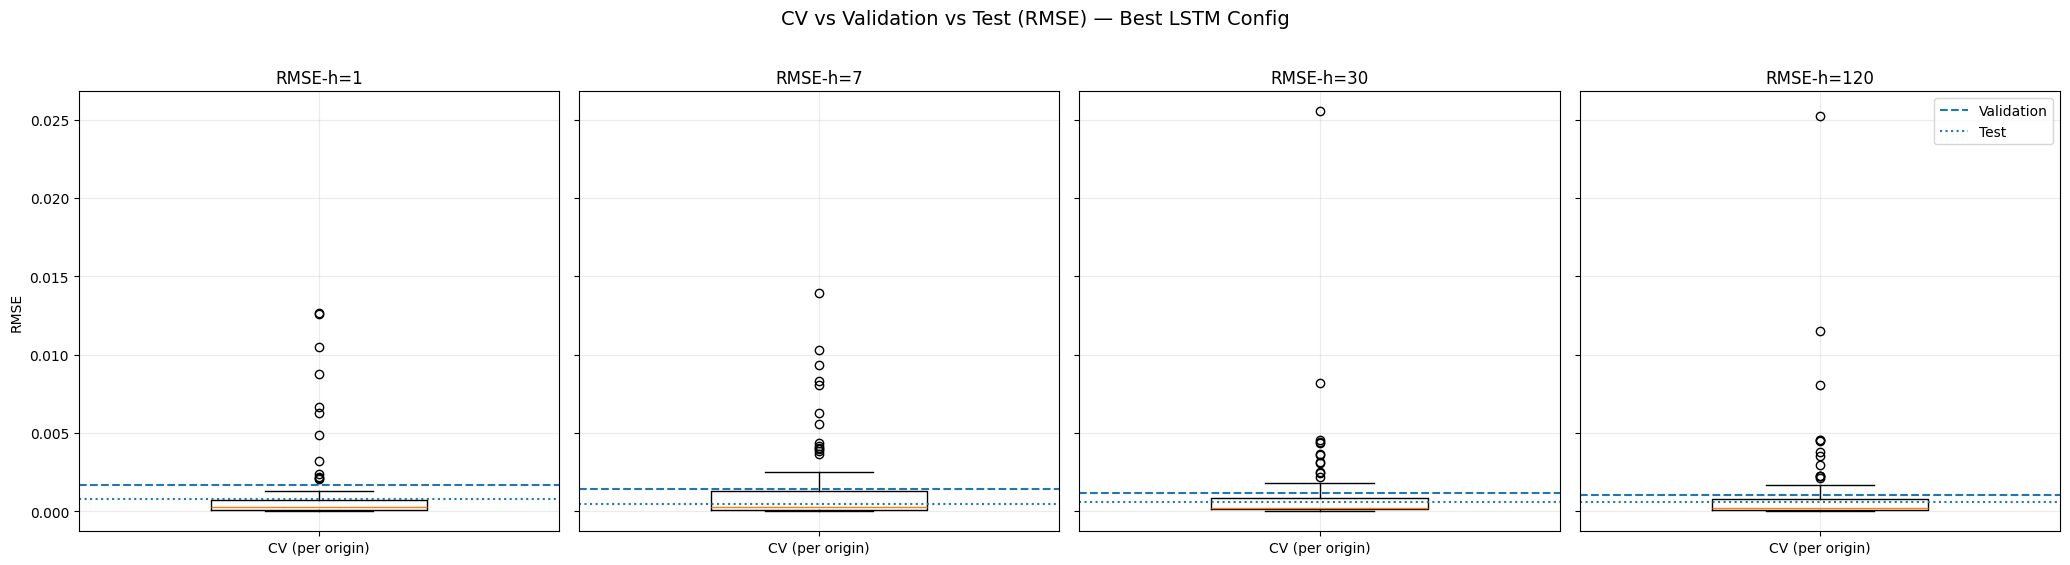

In [86]:
# Boxplots comparing CV distribution (per origin) vs Validation and Test RMSE for the selected best LSTM model across multiple horizons.
def plot_lstm_cv_val_test_boxplots_multi(results_train_lstm: dict, results_validation_lstm: dict, results_test_lstm: dict, horizons: tuple[int, ...] = (1, 7, 30, 120)):
    """
    Plot CV distribution, validation RMSE and test RMSE for the selected LSTM configuration.
    The plot compares per-origin training CV errors against validation and final test errors across multiple horizons.

    Parameters
    ----------
    results_train_lstm (dict): Dictionary returned by LSTM training CV, containing df_all_train.

    results_validation_lstm (dict): Dictionary returned by LSTM validation, containing best_config and best_row.

    results_test_lstm (dict): Dictionary returned by LSTM test evaluation, containing test_results.

    horizons (tuple[int, ...], default=(1, 7, 30, 120)): Forecast horizons to display.

    Returns
    -------
    None: The function displays a matplotlib figure.
    """

    df_all = results_train_lstm["df_all_train"].copy()
    best_cfg = results_validation_lstm["best_config"]

    def normalize_dense_units(value):
        """
        Normalize dense_units values for robust comparison.
        """

        if value is None:
            return "None"

        try:
            if pd.isna(value):
                return "None"
        except Exception:
            pass

        if str(value).lower() in ("none", "nan", "<na>"):
            return "None"

        try:
            return str(int(float(value)))
        except Exception:
            return str(value)

    best_dense_units = normalize_dense_units(best_cfg.dense_units)

    if "dense_units" in df_all.columns:
        df_all["dense_units_normalized"] = df_all["dense_units"].apply(normalize_dense_units)
    else:
        df_all["dense_units_normalized"] = "None"

    # Filter CV rows for the selected best config (LSTM)
    mask = (df_all["lookback"].astype(int).eq(int(best_cfg.lookback))
            & df_all["n_units"].astype(int).eq(int(best_cfg.n_units))
            & df_all["n_layers"].astype(int).eq(int(best_cfg.n_layers))
            & np.isclose(df_all["dropout"].astype(float), float(best_cfg.dropout))
            & np.isclose(df_all["recurrent_dropout"].astype(float), float(best_cfg.recurrent_dropout))
            & df_all["dense_units_normalized"].eq(best_dense_units)
            & np.isclose(df_all["learning_rate"].astype(float), float(best_cfg.learning_rate))
            & df_all["batch_size"].astype(int).eq(int(best_cfg.batch_size))
            & df_all["epochs"].astype(int).eq(int(best_cfg.epochs))
            & df_all["loss"].astype(str).eq(str(best_cfg.loss))
            & df_all["optimizer"].astype(str).eq(str(best_cfg.optimizer))
            & df_all["output_size"].astype(int).eq(int(best_cfg.output_size)))

    df_cv_best = df_all.loc[mask].copy()

    if df_cv_best.empty:
        available_cols = ["lookback",
                          "n_units",
                          "n_layers",
                          "dropout",
                          "recurrent_dropout",
                          "dense_units",
                          "learning_rate",
                          "batch_size",
                          "epochs",
                          "loss",
                          "optimizer",
                          "output_size"]

        available_cols = [c for c in available_cols if c in df_all.columns]

        available = df_all[available_cols].drop_duplicates()

        raise ValueError("No CV rows found for best LSTM config in df_all_train.\n"
                         f"Best cfg: {best_cfg.to_label()}\n"
                         f"Available configs:\n{available}")

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    # Prepare plot
    fig, axes = plt.subplots(1, len(horizons), figsize=(5.2 * len(horizons), 5.5), sharey=True)

    if len(horizons) == 1:
        axes = [axes]

    for ax, h in zip(axes, horizons):

        col = f"RMSE-h={h}"

        if col not in df_cv_best.columns:
            raise ValueError(f"{col} not found in CV results.")

        if col not in results_validation_lstm["best_row"].index:
            raise ValueError(f"{col} not found in validation results.")

        if col not in results_test_lstm["test_results"].columns:
            raise ValueError(f"{col} not found in test results.")

        cv_values = df_cv_best[col].dropna().values
        val_value = float(results_validation_lstm["best_row"][col])
        test_value = float(results_test_lstm["test_results"].iloc[0][col])

        ax.boxplot(cv_values, vert=True, widths=0.45)
        ax.axhline(val_value, linestyle="--", label="Validation")
        ax.axhline(test_value, linestyle=":", label="Test")

        ax.set_title(f"RMSE-h={h}")
        ax.set_xticks([1])
        ax.set_xticklabels(["CV (per origin)"])
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("RMSE")
    axes[-1].legend(loc="upper right")

    fig.suptitle("CV vs Validation vs Test (RMSE) — Best LSTM Config", y=1.02, fontsize=14)

    plt.tight_layout()
    plt.show()


plot_lstm_cv_val_test_boxplots_multi(results_train_lstm=results_train_lstm,
                                     results_validation_lstm=results_validation_lstm,
                                     results_test_lstm=results_test_lstm,
                                     horizons=(1, 7, 30, 120))

In [87]:
# Calculate generalization gaps in percentage terms for each horizon and the average score.
def lstm_generalization_gaps_percent(results_train: dict, results_validation: dict, results_test: dict):
    """
    Calculate generalization gaps in percentage terms for each horizon and the average score.

    Parameters
    ----------
    results_train (dict): Dictionary containing LSTM training CV results.

    results_validation (dict): Dictionary containing LSTM validation results and the selected best configuration.

    results_test (dict): Dictionary containing LSTM final test results.

    Returns
    -------
    df (pd.DataFrame): DataFrame with validation-vs-train, test-vs-train, and test-vs-validation percentage gaps.
    """

    best_cfg = results_validation["best_config"]

    if "summary_train" in results_train:
        df_train = results_train["summary_train"].copy()
    elif "top_train" in results_train:
        df_train = results_train["top_train"].copy()
    else:
        raise KeyError("results_train must contain either 'summary_train' or 'top_train'.")

    def normalize_none(x):
        """
        Convert None-like values to None.
        """
        if x is None:
            return None

        if isinstance(x, float) and np.isnan(x):
            return None

        if isinstance(x, str) and x.strip().lower() in ("none", "nan", ""):
            return None

        return x

    def normalize_config_df(df: pd.DataFrame):
        """
        Normalise LSTM configuration columns before matching.
        """
        df = df.copy()

        int_cols = ["lookback", "n_units", "n_layers", "batch_size", "epochs", "output_size"]
        float_cols = ["dropout", "recurrent_dropout", "learning_rate"]
        str_cols = ["loss", "optimizer"]

        for col in int_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

        for col in float_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)

        for col in str_cols:
            if col in df.columns:
                df[col] = df[col].astype(str).str.strip().str.lower()

        if "dense_units" in df.columns:
            df["dense_units"] = df["dense_units"].apply(normalize_none)

        return df

    df_train_norm = normalize_config_df(df_train)

    cfg_values = {"lookback": int(best_cfg.lookback),
                  "n_units": int(best_cfg.n_units),
                  "n_layers": int(best_cfg.n_layers),
                  "dropout": float(best_cfg.dropout),
                  "recurrent_dropout": float(best_cfg.recurrent_dropout),
                  "dense_units": normalize_none(best_cfg.dense_units),
                  "learning_rate": float(best_cfg.learning_rate),
                  "batch_size": int(best_cfg.batch_size),
                  "epochs": int(best_cfg.epochs),
                  "loss": str(best_cfg.loss).strip().lower(),
                  "optimizer": str(best_cfg.optimizer).strip().lower(),
                  "output_size": int(best_cfg.output_size)}

    mask = pd.Series(True, index=df_train_norm.index)

    for col, value in cfg_values.items():

        if col not in df_train_norm.columns:
            raise KeyError(f"Column '{col}' not found in training results.")

        if value is None:
            mask &= df_train_norm[col].apply(lambda x: normalize_none(x) is None)

        elif isinstance(value, float):
            mask &= np.isclose(df_train_norm[col].astype(float), value, atol=1e-10, rtol=0.0)

        else:
            mask &= df_train_norm[col].eq(value)

    df_train_best = df_train.loc[mask]

    if df_train_best.empty:
        available_cols = ["lookback",
                          "n_units",
                          "n_layers",
                          "dropout",
                          "recurrent_dropout",
                          "dense_units",
                          "learning_rate",
                          "batch_size",
                          "epochs",
                          "loss",
                          "optimizer",
                          "output_size"]

        available_cols = [c for c in available_cols if c in df_train.columns]
        available = df_train[available_cols].drop_duplicates()

        raise ValueError("Best validation LSTM config not found in training results.\n"
                         f"Best cfg: {best_cfg.to_label()}\n"
                         f"Available configs:\n{available}")

    train_row = df_train_best.iloc[0]
    val_row = results_validation["best_row"]
    test_row = results_test["test_results"].iloc[0]

    rmse_cols = sorted([c for c in test_row.index if str(c).startswith("RMSE-h=")], key=lambda x: int(str(x).split("=")[1]))

    metric_cols = rmse_cols + (["score_rmse_mean"] if "score_rmse_mean" in test_row.index else [])

    def pct_gap(a, b, eps: float = 1e-8):
        b = float(b)
        if abs(b) < eps:
            return np.nan
        return (float(a) - b) / b * 100.0

    rows = []

    for m in metric_cols:

        if m not in train_row.index:
            raise KeyError(f"Metric '{m}' not found in training row.")

        if m not in val_row.index:
            raise KeyError(f"Metric '{m}' not found in validation row.")

        if m not in test_row.index:
            raise KeyError(f"Metric '{m}' not found in test row.")

        rows.append({"Metric": m,
                     "Val_vs_Train_%": pct_gap(val_row[m], train_row[m]),
                     "Test_vs_Train_%": pct_gap(test_row[m], train_row[m]),
                     "Test_vs_Val_%": pct_gap(test_row[m], val_row[m])})

    df = pd.DataFrame(rows)
    df = df.set_index("Metric").T

    return df

In [88]:
df_lstm_generalization_gaps = lstm_generalization_gaps_percent(results_train=results_train_lstm,
                                                               results_validation=results_validation_lstm,
                                                               results_test=results_test_lstm)

display_table(df_lstm_generalization_gaps, "LSTM generalization gaps (%):")


LSTM generalization gaps (%):
╒═════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════════╕
│                 │   RMSE-h=1   │   RMSE-h=7   │  RMSE-h=15   │  RMSE-h=30   │  RMSE-h=120  │   score_rmse_mean │
╞═════════════════╪══════════════╪══════════════╪══════════════╪══════════════╪══════════════╪═══════════════════╡
│ Val_vs_Train_%  │ 39.30786805  │ -1.32392406  │ -66.00140480 │  1.48706856  │ -19.28244356 │      -26.62681129 │
├─────────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────────┤
│ Test_vs_Train_% │ -36.02802804 │ -70.22259468 │ -85.43151613 │ -48.57438832 │ -53.25885802 │      -67.32463170 │
├─────────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────────┤
│  Test_vs_Val_%  │ -54.07870865 │ -69.82307511 │ -57.14974756 │ -49.32791694 │ -42.09296708 │      -55.46688256 │
╘═════════════════╧══════════════╧══════════════╧

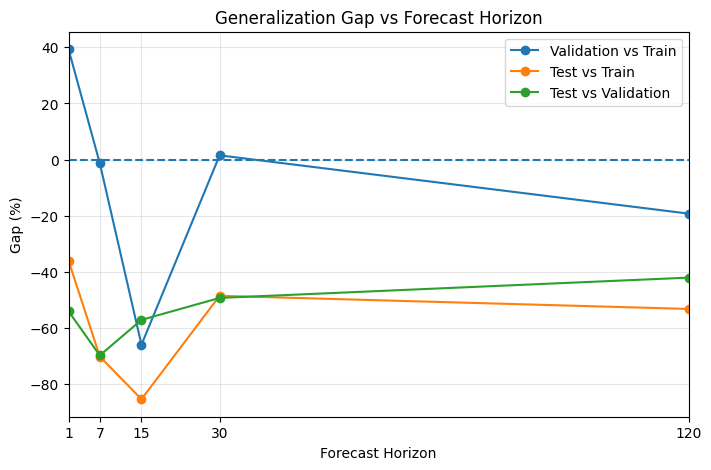

In [89]:
# Plot percentage generalization gaps vs forecast horizon.
df = df_lstm_generalization_gaps.copy()

# Extract horizons from column names
horizons = [int(c.split("=")[1]) for c in df.columns if c.startswith("RMSE-h=")]

# Sort horizons
horizons = sorted(horizons)

val_train = [df.loc["Val_vs_Train_%", f"RMSE-h={h}"] for h in horizons]
test_train = [df.loc["Test_vs_Train_%", f"RMSE-h={h}"] for h in horizons]
test_val = [df.loc["Test_vs_Val_%", f"RMSE-h={h}"] for h in horizons]

plt.figure(figsize=(8,5))

plt.plot(horizons, val_train, marker="o", label="Validation vs Train")
plt.plot(horizons, test_train, marker="o", label="Test vs Train")
plt.plot(horizons, test_val, marker="o", label="Test vs Validation")

plt.axhline(0, linestyle="--")
plt.xticks(horizons)
plt.xlim(min(horizons), max(horizons))

plt.xlabel("Forecast Horizon")
plt.ylabel("Gap (%)")
plt.title("Generalization Gap vs Forecast Horizon")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [90]:
# teste de manwitney

In [91]:
# Naive forecast implementation
def naive_forecast(y_train: pd.Series, h: int):
    """
    Naive forecast (lag-1 / persistence):
    y_hat(t+h) = y(t)
    for all h >= 1
    """

    if len(y_train) < 1:
        raise ValueError("Training series must contain at least one observation.")

    if h < 1:
        raise ValueError("Forecast horizon h must be >= 1.")

    last_value = float(y_train.iloc[-1])

    forecast = np.repeat(last_value, h)

    return forecast.astype(float)


# Seasonal naive forecast implementation
def seasonal_naive_forecast(y_train: pd.Series, h: int, m: int):
    """
    Seasonal naive forecast:
    y_hat(t+h) = y(t+h-m)
    """

    if h < 1:
        raise ValueError("Forecast horizon h must be >= 1.")

    if m is None or m < 2:
        raise ValueError("Seasonal period m must be >= 2 for seasonal naive forecast.")

    if len(y_train) < m:
        raise ValueError("Training series too short for seasonal naive.")

    last_season = y_train.iloc[-m:].values

    reps = int(np.ceil(h / m))
    forecast = np.tile(last_season, reps)[:h]

    return forecast.astype(float)

In [92]:
# Evaluate naive / seasonal naive on a single validation/test origin
def naive_evaluate_single_origin(y_train: pd.Series, y_eval: pd.Series, horizons: tuple[int, ...], m: Optional[int] = None, metric: str = "RMSE",
                                 scale_transformer: Optional[PowerTransformer] = None):
    """
    Evaluate naive or seasonal naive on a single forecast origin.

    Notes
    -----
    - y_train is the information available before the origin.
    - y_eval contains the future observations after the origin.
    - Forecasts and observations are inverted to the original volatility-proxy scale.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if len(y_eval) < hmax:
        raise ValueError(f"Evaluation set too short for hmax={hmax}. len(y_eval)={len(y_eval)}")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    if m is None:
        y_hat = naive_forecast(y_train=y_train, h=hmax)
        row = {"model": "naive", "variant": "naive", "m": None}

    else:
        y_hat = seasonal_naive_forecast(y_train=y_train, h=hmax, m=m)
        row = {"model": "naive", "variant": f"seasonal_naive(m={m})", "m": m}

    y_hat = np.asarray(y_hat, dtype=float)
    y_eval_hmax = y_eval.iloc[:hmax].values.astype(float)

    # Convert forecasts to original volatility-proxy scale
    y_hat_original = inverse_variance_transformation(values=y_hat, reference_series=y_train, yeo_johnson_transformer=scale_transformer,
                                                     clip_negative=True)

    # Convert observed future values to original volatility-proxy scale
    y_eval_hmax_original = inverse_variance_transformation(values=y_eval_hmax, reference_series=y_eval, yeo_johnson_transformer=scale_transformer,
                                                           clip_negative=True)

    rmse_list = []
    mape_list = []
    smape_list = []
    qlike_list = []

    forecast_rows = []

    for h in horizons:
        y_true = np.asarray([y_eval_hmax_original[h - 1]])
        y_pred = np.asarray([y_hat_original[h - 1]])

        row[f"RMSE-h={h}"] = rmse(y_true, y_pred)
        row[f"MAPE-h={h}"], row[f"SMAPE-h={h}"] = mape_smape(y_true, y_pred)
        row[f"QLIKE-h={h}"] = qlike(y_true, y_pred)

        rmse_list.append(row[f"RMSE-h={h}"])
        mape_list.append(row[f"MAPE-h={h}"])
        smape_list.append(row[f"SMAPE-h={h}"])
        qlike_list.append(row[f"QLIKE-h={h}"])

        y_true_h = float(y_eval_hmax_original[h - 1])
        y_pred_h = float(y_hat_original[h - 1])

        forecast_rows.append({"model": "naive",
                              "variant": row["variant"],
                              "m": m,
                              "horizon": int(h),
                              "y_true_vol_proxy": y_true_h,
                              "forecast": y_pred_h,
                              "residual": y_true_h - y_pred_h})

    row["score_rmse_mean"] = float(np.nanmean(rmse_list))
    row["score_mape_mean"] = float(np.nanmean(mape_list))
    row["score_smape_mean"] = float(np.nanmean(smape_list))
    row["score_qlike_mean"] = float(np.nanmean(qlike_list))

    if metric == "RMSE":
        row["score_selected"] = row["score_rmse_mean"]
    elif metric == "MAPE":
        row["score_selected"] = row["score_mape_mean"]
    elif metric == "SMAPE":
        row["score_selected"] = row["score_smape_mean"]
    elif metric == "QLIKE":
        row["score_selected"] = row["score_qlike_mean"]

    row["valid"] = True

    df_forecasts = pd.DataFrame(forecast_rows)

    return row, df_forecasts

In [93]:
# Evaluate naive / seasonal naive using rolling/expanding origins
def naive_evaluate_rolling(y_train: pd.Series, y_eval: pd.Series, horizons: tuple[int, ...], m: Optional[int] = None, metric: str = "RMSE",
                           mode: BacktestMode = "rolling", step: int = 1, window: Optional[int] = None,
                           scale_transformer: Optional[PowerTransformer] = None, stage_name: str = "evaluation"):
    """
    Evaluate naive or seasonal naive using rolling/expanding origins.

    Parameters
    ----------
    y_train (pd.Series): Historical series before the evaluation period.

    y_eval (pd.Series): Validation or test series.

    horizons (tuple[int, ...]): Forecast horizons to evaluate.

    m (Optional[int]): Seasonal period for seasonal naive. If None, use non-seasonal naive.

    metric (str): Metric to use for scoring and model selection ("RMSE", "MAPE", "SMAPE", "QLIKE").

    mode (BacktestMode): "rolling" or "expanding" origins.

    step (int): Step size for rolling origins.

    window (Optional[int]): Window size for rolling origins.

    scale_transformer (Optional[PowerTransformer]): Transformer for variance stabilization.

    stage_name (str): Name used only for progress display.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    blocks = generate_evaluation_backtest_blocks(y_train=y_train, y_val=y_eval, horizons=horizons, mode=mode, window=window, step=step)

    y_full = pd.concat([y_train, y_eval]).copy()

    rows = []
    forecast_frames = []

    for b in tqdm(blocks, desc=f"Naive {stage_name} - origins", unit="origin"):

        try:
            origin_date = y_full.index[b.origin]
        except Exception:
            origin_date = None

        try:
            out, df_forecast = naive_evaluate_single_origin(y_train=b.train,
                                                            y_eval=b.test,
                                                            horizons=horizons,
                                                            m=m,
                                                            metric=metric,
                                                            scale_transformer=scale_transformer)

            if out.get("valid", False):
                out["origin"] = b.origin
                out["origin_date"] = origin_date
                rows.append(out)

                if not df_forecast.empty:
                    df_forecast["origin"] = b.origin
                    df_forecast["origin_date"] = origin_date
                    forecast_frames.append(df_forecast)

        except Exception as e:
            # Keep robust behaviour, but do not stop the full evaluation
            # print(f"Naive failed at origin {b.origin}: {e}")
            continue

    df_by_origin = pd.DataFrame(rows)

    df_forecasts = (pd.concat(forecast_frames, ignore_index=True) if len(forecast_frames) else pd.DataFrame())

    if df_by_origin.empty:
        raise ValueError("No valid naive origins could be evaluated.")

    group_cols = ["model", "variant", "m"]

    rmse_cols = sorted([c for c in df_by_origin.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))
    mape_cols = sorted([c for c in df_by_origin.columns if c.startswith("MAPE-h=")], key=lambda x: int(x.split("=")[1]))
    smape_cols = sorted([c for c in df_by_origin.columns if c.startswith("SMAPE-h=")], key=lambda x: int(x.split("=")[1]))
    qlike_cols = sorted([c for c in df_by_origin.columns if c.startswith("QLIKE-h=")], key=lambda x: int(x.split("=")[1]))

    metric_cols = (rmse_cols + mape_cols + smape_cols + qlike_cols + ["score_rmse_mean",
                                                                      "score_mape_mean",
                                                                      "score_smape_mean",
                                                                      "score_qlike_mean",
                                                                      "score_selected"])

    metric_cols = [c for c in metric_cols if c in df_by_origin.columns]

    df_results = (df_by_origin.groupby(group_cols, dropna=False)[metric_cols].mean().sort_values("score_selected", ascending=True).reset_index())

    id_cols = ["model", "variant", "m"]
    score_cols = ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"]

    ordered_cols = id_cols + rmse_cols + mape_cols + smape_cols + qlike_cols + score_cols
    ordered_cols = [c for c in ordered_cols if c in df_results.columns]

    df_results = df_results[ordered_cols].copy()

    return {"results": df_results,
            "results_by_origin": df_by_origin,
            "df_forecasts": df_forecasts,
            "blocks_n": len(blocks),
            "hmax": max(horizons),
            "model": "naive",
            "variant": "naive" if m is None else f"seasonal_naive(m={m})",
            "m": m}

In [94]:
# Caching mechanism for Naive rolling/expanding test results
def run_or_load_naive_test(cache_dir: str, cache_name: str, y_train: pd.Series, y_val: pd.Series, y_test: pd.Series, horizons: tuple[int, ...], m: Optional[int] = None,
                           metric: str = "RMSE", mode: BacktestMode = "rolling", step: int = 1, window: Optional[int] = None,
                           scale_transformer: Optional[PowerTransformer] = None):
    """
    Run or load final Naive test evaluation using rolling/expanding test origins.

    Cache files
    -----------
    - meta.json
    - test_results.parquet
    - test_results_by_origin.parquet
    - forecasts.parquet

    Notes
    -----
    - Uses y_dev = y_train + y_val as the historical information before the test period.
    - Forecasts and observations are stored on the original volatility-proxy scale.
    """

    def series_signature(y: pd.Series):
        """
        Create a simple signature for a Series based on values and index.
        """
        hashed = pd.util.hash_pandas_object(y, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    cache_path = Path(cache_dir) / cache_name
    cache_path.mkdir(parents=True, exist_ok=True)

    meta_file = cache_path / "meta.json"
    test_file = cache_path / "test_results.parquet"
    test_by_origin_file = cache_path / "test_results_by_origin.parquet"
    forecasts_file = cache_path / "forecasts.parquet"

    expected_meta = {"horizons": list(sorted(set(int(h) for h in horizons))),
                     "mode": mode,
                     "step": step,
                     "window": int(window) if window is not None else None,
                     "m": int(m) if m is not None else None,
                     "metric": metric,
                     "model": "naive",
                     "variant": "naive" if m is None else f"seasonal_naive(m={m})",
                     "stored_forecasts": True,
                     "forecast_scale": "original_volatility_proxy",
                     "test_type": "rolling_expanding_origins",
                     "y_train_signature": series_signature(y_train),
                     "y_train_length": len(y_train),
                     "y_train_start": str(y_train.index.min()),
                     "y_train_end": str(y_train.index.max()),
                     "y_val_signature": series_signature(y_val),
                     "y_val_length": len(y_val),
                     "y_val_start": str(y_val.index.min()),
                     "y_val_end": str(y_val.index.max()),
                     "y_test_signature": series_signature(y_test),
                     "y_test_length": len(y_test),
                     "y_test_start": str(y_test.index.min()),
                     "y_test_end": str(y_test.index.max())}

    required_files_exist = (meta_file.exists() and test_file.exists() and test_by_origin_file.exists() and forecasts_file.exists())

    # Load only if cache exists and metadata matches current input
    if required_files_exist:
        meta = json.loads(meta_file.read_text(encoding="utf-8"))

        cache_is_valid = (meta.get("horizons") == expected_meta["horizons"]
                          and meta.get("mode") == expected_meta["mode"]
                          and meta.get("step") == expected_meta["step"]
                          and meta.get("window") == expected_meta["window"]
                          and meta.get("m") == expected_meta["m"]
                          and meta.get("metric") == expected_meta["metric"]
                          and meta.get("model") == expected_meta["model"]
                          and meta.get("variant") == expected_meta["variant"]
                          and meta.get("stored_forecasts") == expected_meta["stored_forecasts"]
                          and meta.get("forecast_scale") == expected_meta["forecast_scale"]
                          and meta.get("test_type") == expected_meta["test_type"]
                          and meta.get("y_train_signature") == expected_meta["y_train_signature"]
                          and meta.get("y_train_length") == expected_meta["y_train_length"]
                          and meta.get("y_train_start") == expected_meta["y_train_start"]
                          and meta.get("y_train_end") == expected_meta["y_train_end"]
                          and meta.get("y_val_signature") == expected_meta["y_val_signature"]
                          and meta.get("y_val_length") == expected_meta["y_val_length"]
                          and meta.get("y_val_start") == expected_meta["y_val_start"]
                          and meta.get("y_val_end") == expected_meta["y_val_end"]
                          and meta.get("y_test_signature") == expected_meta["y_test_signature"]
                          and meta.get("y_test_length") == expected_meta["y_test_length"]
                          and meta.get("y_test_start") == expected_meta["y_test_start"]
                          and meta.get("y_test_end") == expected_meta["y_test_end"])

        if cache_is_valid:
            df_test = pd.read_parquet(test_file)
            df_test_by_origin = pd.read_parquet(test_by_origin_file)
            df_forecasts_test = pd.read_parquet(forecasts_file)

            return {"results": df_test,
                    "results_by_origin": df_test_by_origin,
                    "df_forecasts": df_forecasts_test,
                    "blocks_n": meta.get("blocks_n"),
                    "hmax": meta.get("hmax"),
                    "model": "naive",
                    "variant": expected_meta["variant"],
                    "m": m,
                    "forecast": df_forecasts_test["forecast"].to_numpy(dtype=float) if "forecast" in df_forecasts_test.columns else np.array([]),
                    "y_true": df_forecasts_test["y_true_vol_proxy"].to_numpy(dtype=float) if "y_true_vol_proxy" in df_forecasts_test.columns else np.array([]),
                    "meta": meta}

        print("Warning: cache metadata does not match current Naive test input. Recomputing Naive test.")

    # Otherwise run rolling/expanding test evaluation
    y_dev = pd.concat([y_train, y_val]).copy()

    out = naive_evaluate_rolling(y_train=y_dev,
                                 y_eval=y_test,
                                 horizons=horizons,
                                 m=m,
                                 metric=metric,
                                 mode=mode,
                                 step=step,
                                 window=window,
                                 scale_transformer=scale_transformer,
                                 stage_name="test")

    meta = {**expected_meta,
            "hmax": int(out.get("hmax", max(horizons))),
            "y_dev_len": int(len(y_dev)),
            "blocks_n": int(out.get("blocks_n", 0))}

    meta_file.write_text(json.dumps(meta, indent=2), encoding="utf-8")

    out["results"].to_parquet(test_file, index=False)
    out["results_by_origin"].to_parquet(test_by_origin_file, index=False)
    out["df_forecasts"].to_parquet(forecasts_file, index=False)

    out["meta"] = meta

    return out

In [95]:
# Evaluate naive benchmark on test set using rolling/expanding origins
cache_dir = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_LSTM_results"

cache_name_naive_test = f"Tese_Bitcoin_Naive_test_{mode}_step{step}_h{max(horizons)}_pkl"

y_dev = pd.concat([y_train, y_val]).copy()

results_naive_test = run_or_load_naive_test(cache_dir=cache_dir,
                                            cache_name=cache_name_naive_test,
                                            y_train=y_train,
                                            y_val=y_val,
                                            y_test=y_test,
                                            horizons=horizons,
                                            m=None,
                                            metric="RMSE",
                                            mode=mode,
                                            step=step,
                                            window=None,
                                            scale_transformer=scale_transformer)

df_naive_test = results_naive_test["results"].copy()

display_table(df_naive_test, "Naive model (rolling test):")

Naive test - origins: 100%|██████████| 68/68 [00:00<00:00, 324.73origin/s]


Naive model (rolling test):
╒════╤═════════╤═══════════╤═════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═════════════════╤══════════════════╤════════════════╤═══════════════╤════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╕
│    │  model  │  variant  │  m  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │    MAPE-h=1     │     MAPE-h=7     │   MAPE-h=15    │   MAPE-h=30   │   MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │  QLIKE-h=1   │  QLIKE-h=7   │  QLIKE-h=15  │  QLIKE-h=30  │  QLIKE-h=120  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │  score_qlike_mean  │   score_selected │
╞════╪═════════╪═══════════╪═════╪════════════╪════════════╪═════════════╪═════════

In [96]:
# Compare LSTM vs Naive on test set
df_lstm_test = results_test_lstm["test_results"].copy()

# Use the rolling/expanding naive test results for LSTM comparison
df_naive_results = results_naive_test["results"].copy()

# Add model identifiers before concatenating
df_lstm_test["Model"] = "LSTM"
df_naive_results["Model"] = "Naive"

# Concatenate results
df_compare_lstm = pd.concat([df_lstm_test, df_naive_results], ignore_index=True)

# Set model name as index
df_compare_lstm = df_compare_lstm.set_index("Model")

# Remove columns that are not useful for final presentation
cols_to_drop = ["model", "variant", "score_selected", "m"]
df_compare_lstm = df_compare_lstm.drop(columns=cols_to_drop, errors="ignore")

# LSTM integer hyperparameters to display without decimal places
int_cols = ["lookback", "n_units", "n_layers", "batch_size", "epochs", "output_size"]

for col in int_cols:
    if col in df_compare_lstm.columns:
        df_compare_lstm[col] = pd.to_numeric(df_compare_lstm[col], errors="coerce")
        df_compare_lstm[col] = df_compare_lstm[col].apply(lambda x: "-" if pd.isna(x) else str(int(x)))

# LSTM non-integer hyperparameters / metadata
lstm_param_cols = ["dropout", "recurrent_dropout", "dense_units", "learning_rate", "loss", "optimizer", "mean_epochs_trained", "best_val_loss", "final_val_loss"]

for col in lstm_param_cols:
    if col in df_compare_lstm.columns:
        df_compare_lstm[col] = (df_compare_lstm[col].astype(object).where(pd.notna(df_compare_lstm[col]), "-"))

# Replace remaining missing values only in non-metric configuration columns
config_cols = int_cols + lstm_param_cols

for col in config_cols:
    if col in df_compare_lstm.columns:
        df_compare_lstm[col] = (df_compare_lstm[col].astype(str).replace("nan", "-").replace("None", "-").replace("<NA>", "-"))

display_table(df_compare_lstm, "LSTM vs Naive (test)")


LSTM vs Naive (test)
╒═════════╤════════════╤═══════════╤════════════╤═══════════╤═════════════════════╤═══════════════╤═════════════════╤══════════════╤══════════╤════════╤═════════════╤═══════════════╤═══════════════════════╤═════════════════════╤═════════════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═════════════════╤══════════════════╤════════════════╤═══════════════╤════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╕
│  Model  │  lookback  │  n_units  │  n_layers  │  dropout  │  recurrent_dropout  │  dense_units  │  learning_rate  │  batch_size  │  epochs  │  loss  │  optimizer  │  output_size  │  mean_epochs_trained  │    best_val_loss    │   final_val_loss    │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │    MAPE-h=1     │

---

# Análise de Resíduos

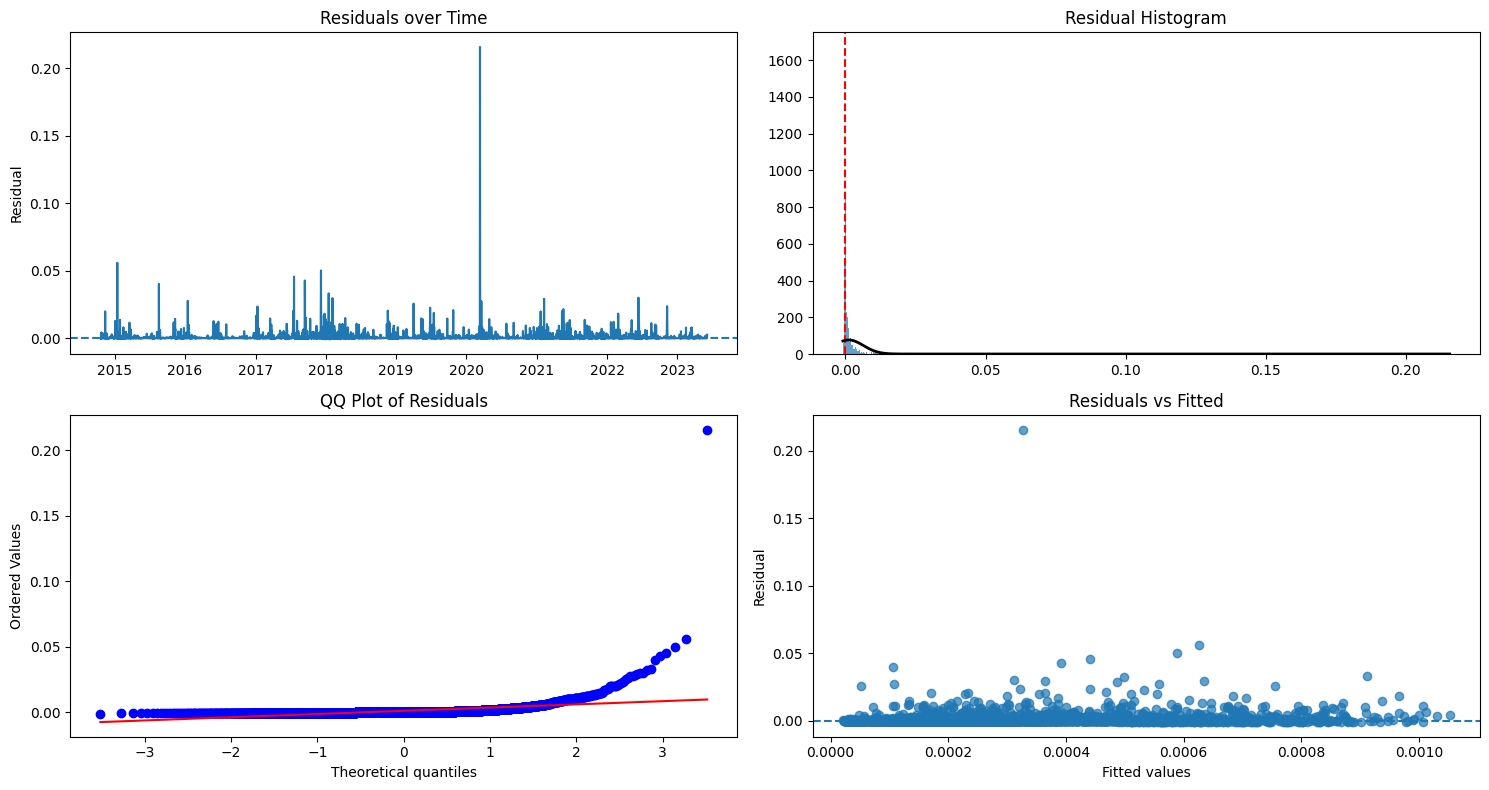

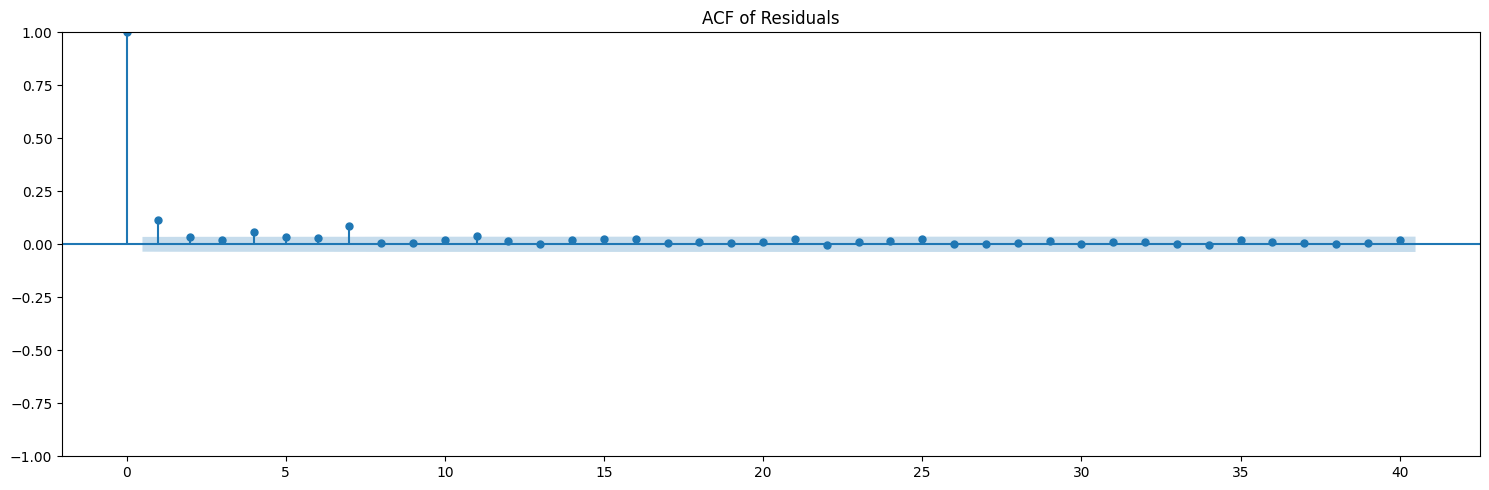


Residual Diagnostics - Final LSTM Model - Original Scale
╒════╤════════════════════════════╤══════════════╕
│    │           Metric           │        Value │
╞════╪════════════════════════════╪══════════════╡
│ 0  │            Mean            │   0.00115397 │
├────┼────────────────────────────┼──────────────┤
│ 1  │           Median           │  -0.00000399 │
├────┼────────────────────────────┼──────────────┤
│ 2  │            Std             │   0.00521172 │
├────┼────────────────────────────┼──────────────┤
│ 3  │          Skewness          │  24.21528564 │
├────┼────────────────────────────┼──────────────┤
│ 4  │          Kurtosis          │ 923.29071864 │
├────┼────────────────────────────┼──────────────┤
│ 5  │        KS Statistic        │   0.35482652 │
├────┼────────────────────────────┼──────────────┤
│ 6  │         KS p-value         │   0.00000000 │
├────┼────────────────────────────┼──────────────┤
│ 7  │ Ljung-Box p-value (lag=20) │   0.00000000 │
╘════╧══════════════════

In [97]:
# Create supervised LSTM sequences
def create_lstm_sequences_for_fit(serie: pd.Series, lookback: int, output_size: int = 1):
    """
    Create supervised sequences for LSTM fitting and fitted-value diagnostics.

    Parameters
    ----------
    serie (pd.Series): Series in the model estimation scale.

    lookback (int): Number of past observations used as input.

    output_size (int): Number of forecast outputs produced by the model.

    Returns
    -------
    X (np.ndarray): LSTM input array with shape (samples, lookback, 1).

    y (np.ndarray): Target array.

    idx (pd.Index): Index corresponding to the first forecast horizon.
    """

    values = serie.values.astype(float)

    X, y, idx = [], [], []

    for i in range(lookback, len(values) - output_size + 1):

        X.append(values[i - lookback:i])
        y.append(values[i:i + output_size])
        idx.append(serie.index[i])

    X = np.asarray(X, dtype=float).reshape(-1, lookback, 1)
    y = np.asarray(y, dtype=float)

    idx = pd.Index(idx)

    return X, y, idx


# Build LSTM model from selected configuration
def build_final_lstm_model(cfg):
    """
    Build final LSTM model from selected configuration.

    Parameters
    ----------
    cfg: Selected LSTM configuration.

    Returns
    -------
    model: Compiled Keras LSTM model.
    """

    model = Sequential()

    if cfg.n_layers == 1:
        model.add(LSTM(units=cfg.n_units,
                       input_shape=(cfg.lookback, 1),
                       dropout=cfg.dropout,
                       recurrent_dropout=cfg.recurrent_dropout))
    else:
        for layer in range(cfg.n_layers):

            return_sequences = layer < cfg.n_layers - 1

            if layer == 0:
                model.add(LSTM(units=cfg.n_units,
                               input_shape=(cfg.lookback, 1),
                               dropout=cfg.dropout,
                               recurrent_dropout=cfg.recurrent_dropout,
                               return_sequences=return_sequences))
            else:
                model.add(LSTM(units=cfg.n_units,
                               dropout=cfg.dropout,
                               recurrent_dropout=cfg.recurrent_dropout,
                               return_sequences=return_sequences))

    if cfg.dense_units is not None:
        model.add(Dense(cfg.dense_units, activation="relu"))

    model.add(Dense(cfg.output_size))

    if cfg.optimizer == "adam":
        optimizer = Adam(learning_rate=cfg.learning_rate)
    else:
        raise ValueError(f"Unsupported optimizer: {cfg.optimizer}")

    model.compile(optimizer=optimizer, loss=cfg.loss)

    return model


# Final LSTM model fitting and residual diagnostics
def fit_final_lstm_model(y_train: pd.Series, y_val: pd.Series, cfg, scale_transformer: Optional[PowerTransformer] = None, residual_scale: str = "original", residual_horizon: int = 1,
                         validation_split: float = 0.1, patience: int = 10, verbose: int = 0):
    """
    Fit the final LSTM model on the development set (train + validation).

    Parameters
    ----------
    y_train, y_val (pd.Series): Series in the model estimation scale.

    cfg: Selected LSTM configuration.

    scale_transformer (PowerTransformer, optional): Required only when the series was transformed using Yeo-Johnson.

    residual_scale (str {"original", "model"}):
        - "model": residuals are computed in the model estimation scale.
        - "original": fitted values and observations are inverted to the original
          volatility-proxy scale before residuals are computed.

    residual_horizon (int): Forecast horizon used to compute fitted residuals.

    validation_split (float): Validation split used during final LSTM fitting.

    patience (int): Early stopping patience.

    verbose (int): Keras verbosity level.

    Returns
    -------
    dict with:
    - y_dev
    - y_dev_used
    - model
    - fit
    - fitted_values
    - residuals
    - residual_scale
    """

    if residual_scale not in ("original", "model"):
        raise ValueError("residual_scale must be either 'original' or 'model'.")

    if residual_horizon < 1 or residual_horizon > cfg.output_size:
        raise ValueError(f"residual_horizon must be between 1 and cfg.output_size={cfg.output_size}.")

    y_dev = pd.concat([y_train, y_val]).copy()

    if len(y_dev) <= cfg.lookback + cfg.output_size:
        raise ValueError("Development series is too short for the selected LSTM lookback and output size.")

    X_dev, y_dev_supervised, idx_dev = create_lstm_sequences_for_fit(serie=y_dev,
                                                                     lookback=cfg.lookback,
                                                                     output_size=cfg.output_size)

    model = build_final_lstm_model(cfg)

    early_stop = EarlyStopping(monitor="val_loss",
                               patience=patience,
                               restore_best_weights=True)

    fit = model.fit(X_dev,
                    y_dev_supervised,
                    epochs=cfg.epochs,
                    batch_size=cfg.batch_size,
                    validation_split=validation_split,
                    callbacks=[early_stop],
                    verbose=verbose,
                    shuffle=False)

    y_pred = model.predict(X_dev, verbose=0)

    horizon_pos = residual_horizon - 1

    observed_model_scale = pd.Series(y_dev_supervised[:, horizon_pos],
                                     index=idx_dev,
                                     name="observed_model_scale")

    fitted_model_scale = pd.Series(y_pred[:, horizon_pos],
                                   index=idx_dev,
                                   name="fitted_model_scale")

    y_dev_used = observed_model_scale.copy()

    if residual_scale == "model":

        fitted_values = fitted_model_scale.rename("fitted")
        residuals = pd.Series(observed_model_scale.values - fitted_values.values, index=observed_model_scale.index, name="residuals")

    else:

        observed_original_values = inverse_variance_transformation(values=observed_model_scale.values.astype(float),
                                                                   reference_series=y_dev,
                                                                   yeo_johnson_transformer=scale_transformer,
                                                                   clip_negative=True)

        fitted_original_values = inverse_variance_transformation(values=fitted_model_scale.values.astype(float),
                                                                 reference_series=y_dev,
                                                                 yeo_johnson_transformer=scale_transformer,
                                                                 clip_negative=True)

        observed_original = pd.Series(observed_original_values, index=observed_model_scale.index, name="observed_original_scale")

        fitted_values = pd.Series(fitted_original_values, index=fitted_model_scale.index, name="fitted")

        residuals = pd.Series(observed_original.values - fitted_values.values, index=fitted_values.index, name="residuals")

    return {"y_dev": y_dev,
            "y_dev_used": y_dev_used,
            "model": model,
            "fit": fit,
            "fitted_values": fitted_values,
            "residuals": residuals,
            "residual_scale": residual_scale,
            "residual_horizon": residual_horizon}


def residual_diagnostics_table(residuals: pd.Series, ljung_box_lags: int = 20):
    """
    Compute a compact residual diagnostics table.
    """

    residuals = residuals.dropna().copy()

    lb = acorr_ljungbox(residuals, lags=[ljung_box_lags], return_df=True)
    ks_stat, ks_pvalue = kstest(residuals.values, "norm", args=(float(residuals.mean()), float(residuals.std(ddof=0))))

    out = pd.DataFrame({"Metric": ["Mean",
                                   "Median",
                                   "Std",
                                   "Skewness",
                                   "Kurtosis",
                                   "KS Statistic",
                                   "KS p-value",
                                   f"Ljung-Box p-value (lag={ljung_box_lags})"],

                        "Value": [float(residuals.mean()),
                                  float(residuals.median()),
                                  float(residuals.std()),
                                  float(residuals.skew()),
                                  float(residuals.kurtosis()),
                                  float(ks_stat),
                                  float(ks_pvalue),
                                  float(lb["lb_pvalue"].iloc[0])]})

    return out


def plot_residual_diagnostics(residuals: pd.Series, fitted_values: pd.Series, acf_lags: int = 40):
    """
    Plot standard residual diagnostics for the final LSTM model.
    """

    residuals = residuals.dropna().copy()
    fitted_values = fitted_values.loc[residuals.index].copy()

    fig, axes = plt.subplots(2, 2, figsize=(15, 8))

    # Residual time plot
    axes[0, 0].plot(residuals.index, residuals.values)
    axes[0, 0].axhline(0, linestyle="--")
    axes[0, 0].set_title("Residuals over Time")
    axes[0, 0].set_ylabel("Residual")

    # Histogram with Freedman–Diaconis bins
    n_bins, _ = freedman_diaconis_bins(residuals.values)
    axes[0, 1].hist(residuals.values, bins=n_bins, density=True, alpha=0.7)
    axes[0, 1].axvline(0, linestyle="--", color="red")

    x = np.linspace(residuals.min(), residuals.max(), 500)
    axes[0, 1].plot(x, norm.pdf(x, residuals.mean(), residuals.std()), linewidth=2, color="black")
    axes[0, 1].set_title("Residual Histogram")

    # QQ plot
    stats.probplot(residuals.values, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title("QQ Plot of Residuals")

    # Residuals vs fitted
    axes[1, 1].scatter(fitted_values.values, residuals.values, alpha=0.7)
    axes[1, 1].axhline(0, linestyle="--")
    axes[1, 1].set_title("Residuals vs Fitted")
    axes[1, 1].set_xlabel("Fitted values")
    axes[1, 1].set_ylabel("Residual")

    plt.tight_layout()
    plt.show()

    # ACF plot in a separate figure
    fig, ax = plt.subplots(figsize=(15, 5))
    plot_acf(residuals, lags=acf_lags, ax=ax)
    ax.set_title("ACF of Residuals")
    plt.tight_layout()
    plt.show()


def run_final_lstm_residual_diagnostics(y_train: pd.Series,
                                        y_val: pd.Series,
                                        cfg,
                                        ljung_box_lags: int = 20,
                                        acf_lags: int = 40,
                                        scale_transformer: Optional[PowerTransformer] = None,
                                        residual_scale: str = "original",
                                        residual_horizon: int = 1,
                                        validation_split: float = 0.1,
                                        patience: int = 10,
                                        verbose: int = 0):
    """
    Full residual diagnostics workflow for the final LSTM model.
    """

    fit_pack = fit_final_lstm_model(y_train=y_train,
                                    y_val=y_val,
                                    cfg=cfg,
                                    scale_transformer=scale_transformer,
                                    residual_scale=residual_scale,
                                    residual_horizon=residual_horizon,
                                    validation_split=validation_split,
                                    patience=patience,
                                    verbose=verbose)

    diag_table = residual_diagnostics_table(residuals=fit_pack["residuals"],
                                            ljung_box_lags=ljung_box_lags)

    plot_residual_diagnostics(residuals=fit_pack["residuals"],
                              fitted_values=fit_pack["fitted_values"],
                              acf_lags=acf_lags)

    return {"y_dev": fit_pack["y_dev"],
            "y_dev_used": fit_pack["y_dev_used"],
            "fit": fit_pack["fit"],
            "model": fit_pack["model"],
            "fitted_values": fit_pack["fitted_values"],
            "residuals": fit_pack["residuals"],
            "residual_scale": fit_pack["residual_scale"],
            "residual_horizon": fit_pack["residual_horizon"],
            "diagnostics_table": diag_table}


best_cfg_lstm = results_validation_lstm["best_config"]

residual_pack_lstm = run_final_lstm_residual_diagnostics(y_train=y_train,
                                                         y_val=y_val,
                                                         cfg=best_cfg_lstm,
                                                         ljung_box_lags=20,
                                                         acf_lags=40,
                                                         scale_transformer=scale_transformer,
                                                         residual_scale="original",
                                                         residual_horizon=1,
                                                         validation_split=0.1,
                                                         patience=10,
                                                         verbose=0)

display_table(residual_pack_lstm["diagnostics_table"], "Residual Diagnostics - Final LSTM Model - Original Scale")

---

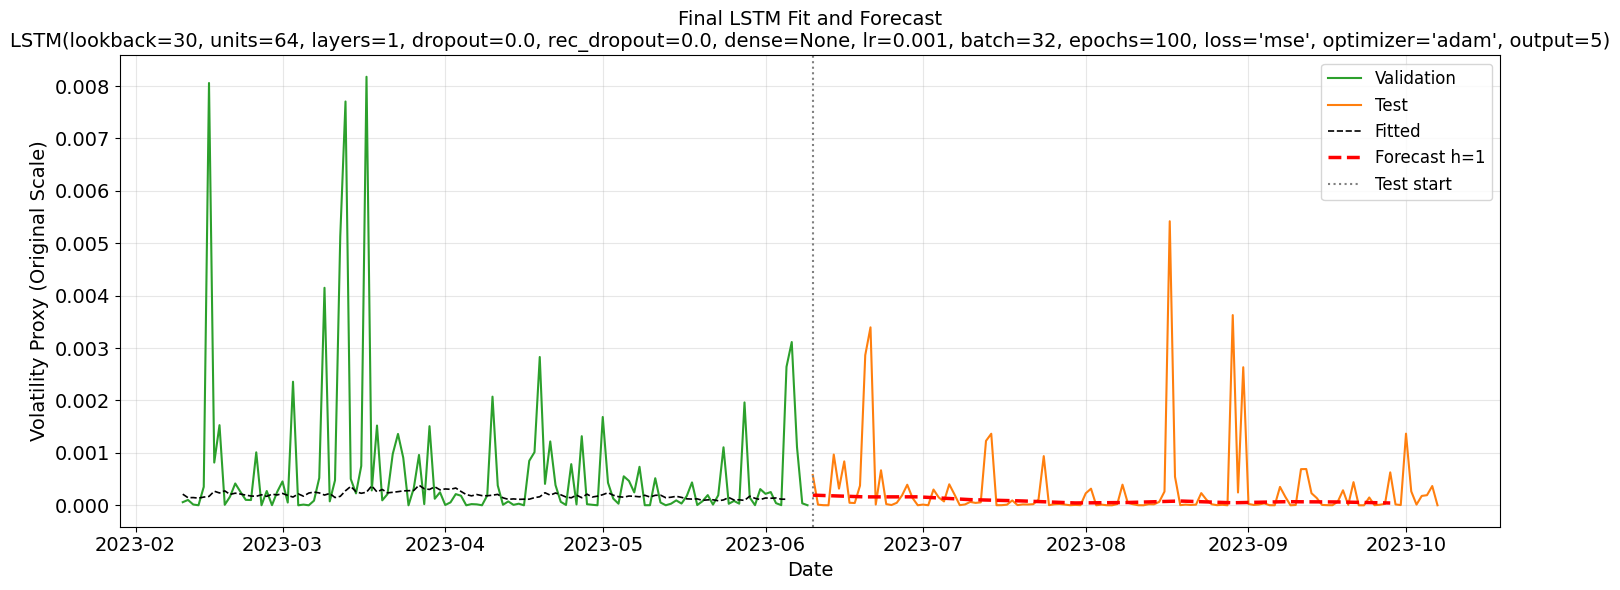

In [98]:
# Final SVR fitted values and stored rolling forecast vs observed test values
window = 120
h_plot = 1

# Development sample
y_dev = pd.concat([y_train, y_val]).copy()
y_full = pd.concat([y_dev, y_test]).copy()

# Fitted values already computed from final LSTM residual diagnostics
fitted_original = residual_pack_lstm["fitted_values"].copy()
fitted_original.name = "Fitted"

# Stored test forecasts from rolling/expanding test evaluation
df_forecasts_test_lstm = results_test_lstm["df_forecasts_test"].copy()

if df_forecasts_test_lstm.empty:
    raise ValueError("results_test_lstm['df_forecasts_test'] is empty. Check the test evaluation output.")

required_cols = ["origin", "horizon", "y_true_vol_proxy", "forecast", "residual"]
missing_cols = [c for c in required_cols if c not in df_forecasts_test_lstm.columns]

if len(missing_cols) > 0:
    raise ValueError(f"df_forecasts_test_lstm is missing required columns: {missing_cols}")

# Select forecast horizon
df_h = df_forecasts_test_lstm.loc[df_forecasts_test_lstm["horizon"].eq(h_plot)].copy()

if df_h.empty:
    raise ValueError(f"No stored LSTM forecasts found for horizon h={h_plot}.")

# Recover actual target date of each stored forecast
target_positions = (df_h["origin"].astype(int).values + df_h["horizon"].astype(int).values - 1)

valid_mask = (target_positions >= 0) & (target_positions < len(y_full))

df_h = df_h.loc[valid_mask].copy()
target_positions = target_positions[valid_mask]

df_h["target_date"] = y_full.index[target_positions]
df_h = df_h.sort_values("target_date").reset_index(drop=True)

# Limit plotting window
y_dev_plot = y_dev.iloc[-window:].copy()

y_train_plot = y_train.loc[y_dev_plot.index.intersection(y_train.index)]
y_val_plot = y_val.loc[y_dev_plot.index.intersection(y_val.index)]

y_test_plot = y_test.iloc[:window].copy()

# Convert observed train/validation/test series to original volatility-proxy scale
y_train_plot_original = pd.Series(inverse_variance_transformation(values=y_train_plot.values.astype(float),
                                                                  reference_series=y_train,
                                                                  yeo_johnson_transformer=scale_transformer,
                                                                  clip_negative=True), index=y_train_plot.index, name="Train")

y_val_plot_original = pd.Series(inverse_variance_transformation(values=y_val_plot.values.astype(float),
                                                                reference_series=y_val,
                                                                yeo_johnson_transformer=scale_transformer,
                                                                clip_negative=True), index=y_val_plot.index, name="Validation")

y_test_plot_original = pd.Series(inverse_variance_transformation(values=y_test_plot.values.astype(float),
                                                                reference_series=y_test,
                                                                yeo_johnson_transformer=scale_transformer,
                                                                clip_negative=True), index=y_test_plot.index, name="Test")

# Select fitted values within the plotted development window
fitted_plot_original = fitted_original.loc[fitted_original.index.intersection(y_dev_plot.index)].copy()

# Select forecasts within the plotted test window
df_h_plot = df_h[df_h["target_date"].isin(y_test_plot_original.index)].copy()

forecast_plot_original = pd.Series(df_h_plot["forecast"].values.astype(float), index=df_h_plot["target_date"], name="Forecast")

plt.figure(figsize=(15, 6))

# Train
if len(y_train_plot_original) > 0:
    plt.plot(y_train_plot_original.index, y_train_plot_original.values, color="tab:blue", label="Train")

# Validation
if len(y_val_plot_original) > 0:
    plt.plot(y_val_plot_original.index, y_val_plot_original.values, color="tab:green", label="Validation")

# Test
plt.plot(y_test_plot_original.index, y_test_plot_original.values, color="tab:orange", label="Test")

# Fitted
if len(fitted_plot_original) > 0:
    plt.plot(fitted_plot_original.index, fitted_plot_original.values, linestyle="--", linewidth=1.2, color="black", label="Fitted")

# Forecast
if len(forecast_plot_original) > 0:
    plt.plot(forecast_plot_original.index, forecast_plot_original.values, linestyle="--", linewidth=2.5, color="red", label=f"Forecast h=1")

# Split line
plt.axvline(y_test.index[0], linestyle=":", linewidth=1.5, color="grey", label="Test start")

plt.title(f"Final LSTM Fit and Forecast\n{results_validation_lstm['best_config'].to_label()}", fontsize=14)

plt.xlabel("Date", fontsize=14)
plt.ylabel("Volatility Proxy (Original Scale)", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

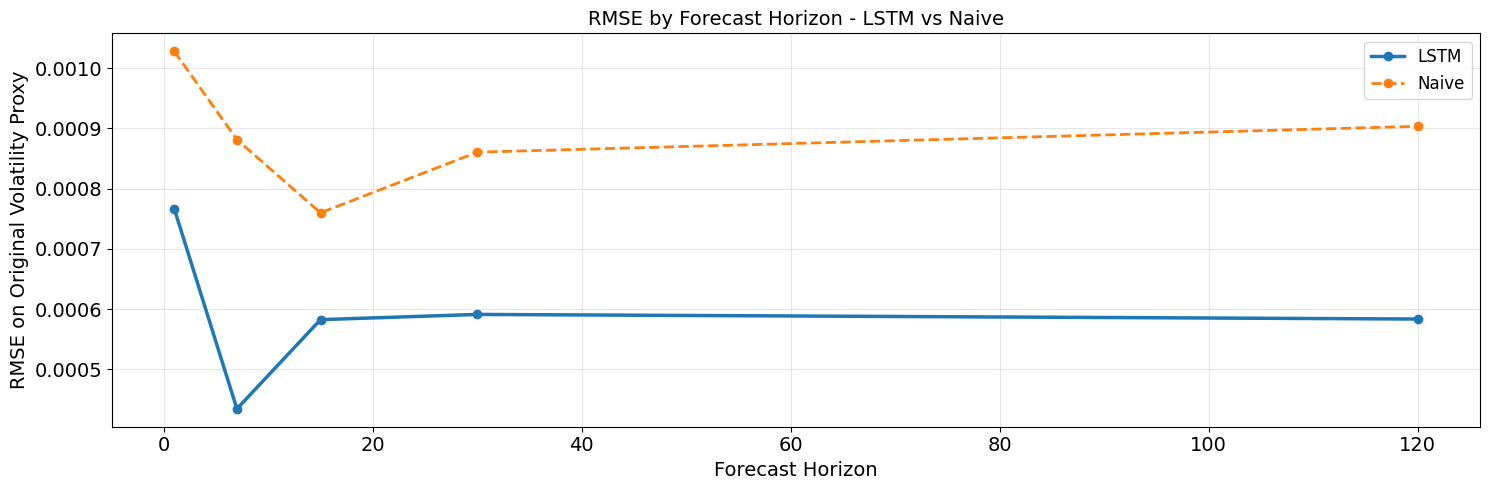

In [99]:
# Compare LSTM vs Naive on test set across horizons
def plot_LSTM_vs_naive_rmse_by_horizon(df_compare: pd.DataFrame):
    """
    Plot RMSE vs horizon comparing LSTM and Naive.
    Assumes RMSE values were computed on the original volatility-proxy scale.
    """

    # Ensure index is clean
    df_compare = df_compare.copy()
    df_compare.index = df_compare.index.astype(str).str.strip()

    # Identify RMSE columns
    rmse_cols = sorted([c for c in df_compare.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))

    if len(rmse_cols) == 0:
        raise ValueError("No RMSE-h= columns found in df_compare.")

    if "LSTM" not in df_compare.index:
        raise ValueError(f"'LSTM' not found in df_compare index. Available index values: {list(df_compare.index)}")

    if "Naive" not in df_compare.index:
        raise ValueError(f"'Naive' not found in df_compare index. Available index values: {list(df_compare.index)}")

    horizons = [int(c.split("=")[1]) for c in rmse_cols]

    # Select rows by index
    lstm_row = df_compare.loc["LSTM"]
    naive_row = df_compare.loc["Naive"]

    lstm_rmse = lstm_row[rmse_cols].astype(float).values
    naive_rmse = naive_row[rmse_cols].astype(float).values

    plt.figure(figsize=(15, 5))

    plt.plot(horizons, lstm_rmse, marker="o", linewidth=2.5, label="LSTM")
    plt.plot(horizons, naive_rmse, marker="o", linestyle="--", linewidth=2, label="Naive")

    plt.title("RMSE by Forecast Horizon - LSTM vs Naive", fontsize=14)
    plt.xlabel("Forecast Horizon", fontsize=14)
    plt.ylabel("RMSE on Original Volatility Proxy", fontsize=14)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_LSTM_vs_naive_rmse_by_horizon(df_compare_lstm)

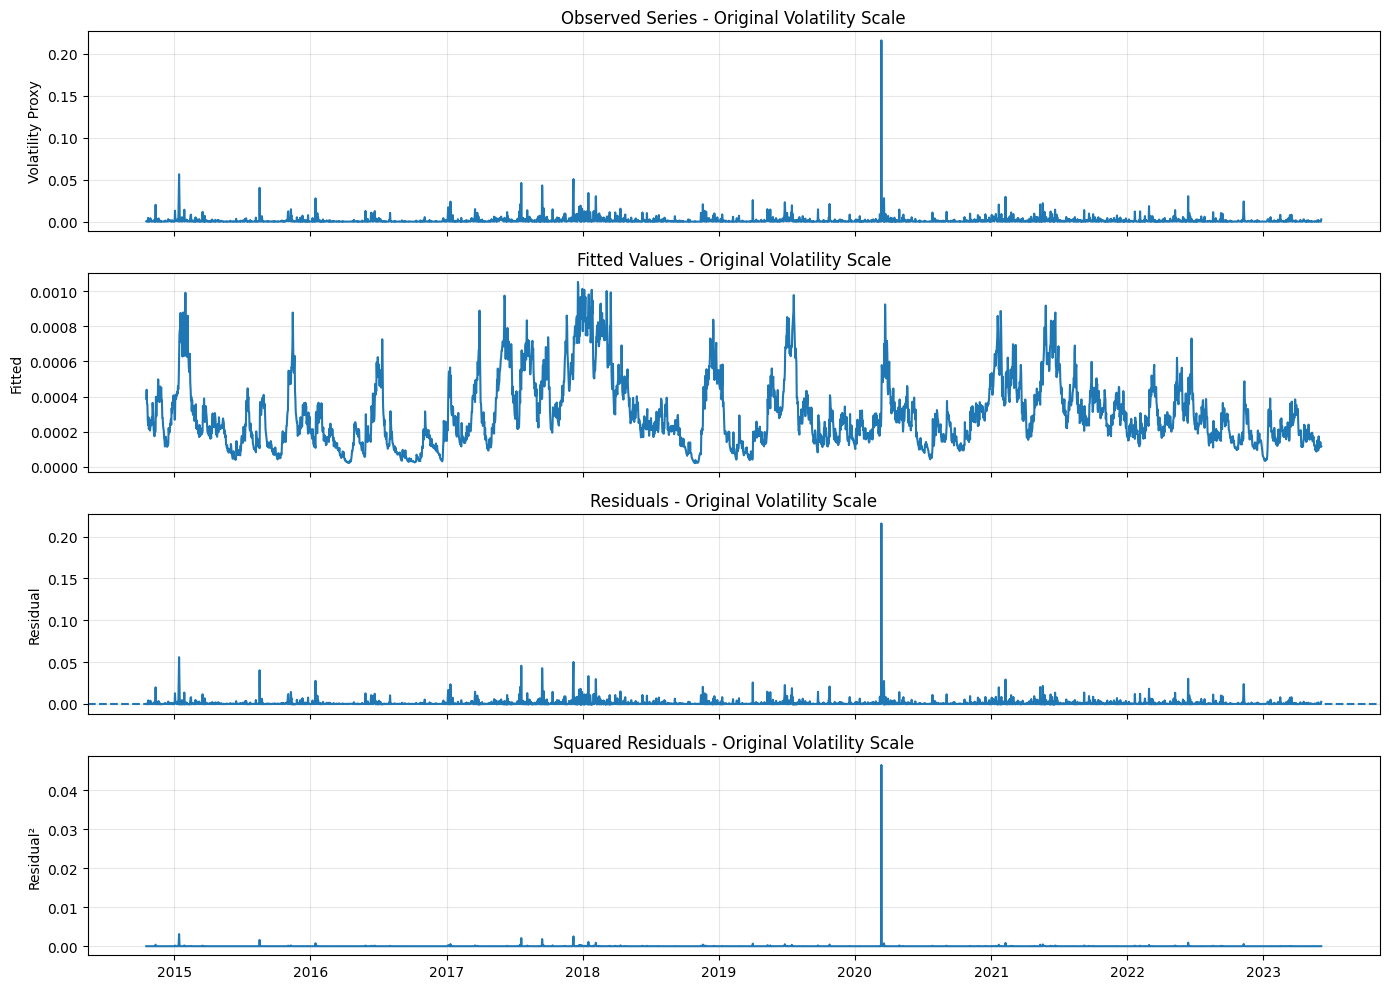

In [100]:
# Plot LSTM fit diagnostics: observed, fitted, residuals and squared residuals
fit = residual_pack_lstm["fit"]
y_dev_used = residual_pack_lstm["y_dev_used"]
fitted = residual_pack_lstm["fitted_values"]
residuals = residual_pack_lstm["residuals"]

# Convert observed development series to original volatility-proxy scale
y_dev_original = pd.Series(inverse_variance_transformation(values=y_dev_used.values.astype(float), reference_series=residual_pack_lstm["y_dev"],
                                                           yeo_johnson_transformer=scale_transformer), index=y_dev_used.index, name="Observed")

# Align all series to the same index
common_index = y_dev_original.index.intersection(fitted.index).intersection(residuals.index)

y_dev_plot = y_dev_original.loc[common_index]
fitted_plot = fitted.loc[common_index]
residuals_plot = residuals.loc[common_index]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Observed series
axes[0].plot(y_dev_plot.index, y_dev_plot.values)
axes[0].set_title("Observed Series - Original Volatility Scale")
axes[0].set_ylabel("Volatility Proxy")

# Fitted values
axes[1].plot(fitted_plot.index, fitted_plot.values)
axes[1].set_title("Fitted Values - Original Volatility Scale")
axes[1].set_ylabel("Fitted")

# Residuals
axes[2].plot(residuals_plot.index, residuals_plot.values)
axes[2].axhline(0, linestyle="--")
axes[2].set_title("Residuals - Original Volatility Scale")
axes[2].set_ylabel("Residual")

# Squared residuals
axes[3].plot(residuals_plot.index, residuals_plot.values**2)
axes[3].set_title("Squared Residuals - Original Volatility Scale")
axes[3].set_ylabel("Residual²")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()